In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from pathlib import Path
import networkx as nx

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16

In [2]:


repo_url = "https://github.com/ccg-esb-lab/profileX.git"
repo_name = "profileX"

# Clone only if missing
if not Path(repo_name).exists():
    !git clone {repo_url}

# Root paths
REPO_ROOT = Path(repo_name).resolve()
print("Repo root:", REPO_ROOT)

base_path = REPO_ROOT

# Standard project folders
data_path = REPO_ROOT / "data/"
figures_path = REPO_ROOT / "figures/"
runs_path = REPO_ROOT / "runs/"

# Create folders if needed
for path in [data_path, figures_path, runs_path]:
    path.mkdir(parents=True, exist_ok=True)
    print(path)



Repo root: /content/profileX
/content/profileX/data
/content/profileX/figures
/content/profileX/runs


In [3]:
#fileName_OD="N3_OD"
#fileName_Freq="N3_Freq"

baseline="EEEEE"

ruta_mapping = {
        "AAAAA": "M9+Leu+Phe+Met",
        "BBBB": "M9+Leu+Phe",
        "CCC": "M9+Leu+Met",
        "DDDDD": "M9+Phe+Met",
        "EEEEE": "M9",
    }

def ruta_label(mapping, r):
    if mapping is None:
        return r
    return mapping.get(r, r)

FREQ_LABEL_MAP = {
    "pct_F": r"$\Delta$Phe",
    "pct_L": r"$\Delta$Leu",
    "pct_M": r"$\Delta$Met",
}


FREQ_COLORS = {
    "pct_F": "#362847",
    "pct_L": "#7C8838",
    "pct_M": "#A52B29",
}



_DEFAULT_COMP_PALETTE = ["#FF6B6B", "#3178B1", "#2ECC71"]  # F, L, M
CONSTANT_PATHS = ["AAAAA", "BBBB", "CCC", "DDDDD", "EEEEE"]


strain_colors = ["#177E89", "#A52B29",  "#FF6B6B",  "#FFBB5F", "#00A6A6", "#362847", "#7C8838"]
strain_lbls=['trpC', 'metA', 'ilvA', 'thrC', 'tyrA', 'pheA', 'leuB'] #

OUTCOME_COLORS = {
    "collapse": "#393349",
    "competitive_exclusion": "#6479BC",
    "coexistence": "#DBC264",
}

REGIME_COLORS = {
    "constant": "#61AC86",
    "feedback": "#177E89",
    "optimal": "#FF6B6B",
    "random": "#8590AE",
    "median": "#393349",
}

MEDIA_LABEL_MAP = {
    "M9": "M9",
    "f":  "M9+Leu",
    "l":  "M9+Phe",
    "m":  "M9+Met",
}

LABEL_COLOR_MAP = {
    "M9+Leu+Phe+Met": "#000000",
    "M9+Leu+Phe":     "#FFC857",
    "M9+Leu+Met":     "#2ECC71",
    "M9+Phe+Met":     "#3178B1",
    "M9+Leu":     "#7C8838",
    "M9+Met":     "#A52B29",
    "M9+Phe":     "#362847",
    "M9":             "#777380",
    "Feedback":       "#FFFF00",
}

## 2-Strain

In [4]:
bg_od = 0.086

In [5]:


def load_frequency_data_csv(csv_file):
    """
    Load OD + frequency data from a local CSV file.
    """

    df = pd.read_csv(csv_file)

    # Convert numeric columns
    numeric_cols = [
        "Day",
        "OD_R1", "OD_R2", "OD_R3", "OD_R4",
        "freq_pheA", "freq_leuB", "freq_metA"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    # Background subtraction only for OD columns
    od_cols = ["OD_R1", "OD_R2", "OD_R3", "OD_R4"]

    for col in od_cols:
        if col in df.columns:
            df[col] = df[col] - bg_od

    # Avoid negative OD
    df[od_cols] = df[od_cols].clip(lower=0)

    return df

In [7]:
csv_file = data_path / "ProfileX_data_N2_OD_Freq.csv"
print(csv_file)
df = load_frequency_data_csv(csv_file)

print(df.head())

/content/profileX/data/ProfileX_data_N2_OD_Freq.csv
   Day coculture media  OD_R1  OD_R2  OD_R3  OD_R4  CFUs_pheA  CFUs_leuB  \
0    1        FM    M9  0.021  0.018  0.030  0.026        NaN        NaN   
1    1        FM    fm  0.114  0.155  0.128  0.114        NaN        NaN   
2    1        FM     f  0.078  0.114  0.074  0.072        NaN        NaN   
3    1        FM     m  0.107  0.080  0.072  0.079        NaN        NaN   
4    2        FM    M9  0.006  0.000  0.008  0.004        NaN        NaN   

   CFUs_metA  
0        NaN  
1        NaN  
2        NaN  
3        NaN  
4        NaN  


In [8]:

df["OD_mean"] = df[["OD_R1", "OD_R2", "OD_R3", "OD_R4"]].mean(axis=1)
df["OD_std"] = df[["OD_R1", "OD_R2", "OD_R3", "OD_R4"]].std(axis=1)



In [9]:
def plot_od_timeseries_by_media(
    df,
    media_values=("M9", "f", "l", "m"),
    coculture=None,
    od_cols=("OD_R1", "OD_R2", "OD_R3", "OD_R4"),
    time_col="Day",
    media_col="media",
    coculture_col="coculture",
    show_raw=True,
    title=""
):
    import numpy as np
    import matplotlib.pyplot as plt

    if coculture is not None:
        df = df[df[coculture_col] == coculture].copy()

    fig, ax = plt.subplots(figsize=(6, 4))

    for media in media_values:

        this_df = df[df[media_col] == media].copy()

        if len(this_df) == 0:
            print(f"No data for media={media}, coculture={coculture}")
            continue

        label = MEDIA_LABEL_MAP.get(media, media)

        color = LABEL_COLOR_MAP.get(
            label,
            "gray"
        )

        df_long = this_df.melt(
            id_vars=[time_col],
            value_vars=od_cols,
            var_name="replicate",
            value_name="OD"
        ).dropna(subset=["OD"])

        df_summary = (
            df_long
            .groupby(time_col)["OD"]
            .agg(
                OD_mean="mean",
                OD_std="std",
                n="count"
            )
            .reset_index()
        )

        df_summary["OD_sem"] = (
            df_summary["OD_std"] /
            np.sqrt(df_summary["n"])
        )

        if show_raw:
            ax.scatter(
                df_long[time_col],
                df_long["OD"],
                alpha=0.18,
                s=12,
                color=color
            )

        ax.errorbar(
            df_summary[time_col],
            df_summary["OD_mean"],
            yerr=df_summary["OD_sem"],
            marker="o",
            linewidth=3,
            capsize=3,
            color=color,
            label=label
        )

    ax.set_xticks([1, 2, 3, 4, 5])

    ax.set_xlabel("Time (days)")
    ax.set_ylabel(r"Optical Density (OD$_{630}$)")



    ax.set_title(title)

    ax.legend(
        title="Environment",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    #plt.show()

No data for media=m, coculture=LF
Exporting to /content/profileX/figures/expe-constant-pairwise-LF.pdf


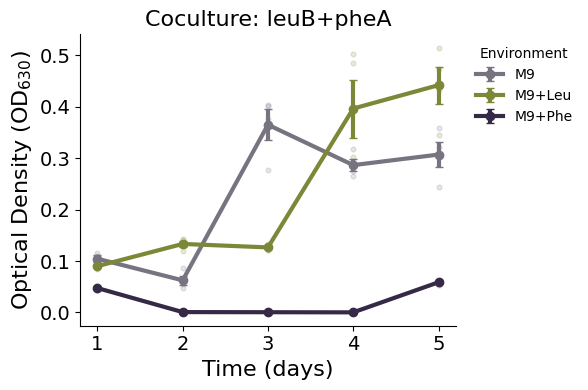

No data for media=f, coculture=LM
Exporting to /content/profileX/figures/expe-constant-pairwise-LM.pdf


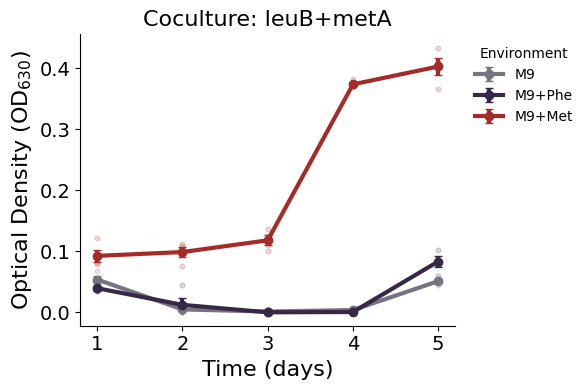

No data for media=l, coculture=FM
Exporting to /content/profileX/figures/expe-constant-pairwise-FM.pdf


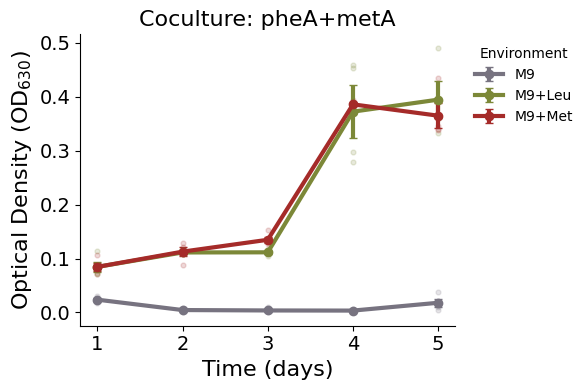

In [10]:
plot_od_timeseries_by_media(df, coculture="LF", title='Coculture: leuB+pheA')
outfile = figures_path / f"expe-constant-pairwise-LF.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()


plot_od_timeseries_by_media(df, coculture="LM", title='Coculture: leuB+metA')
outfile = figures_path / f"expe-constant-pairwise-LM.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

plot_od_timeseries_by_media(df, coculture="FM", title='Coculture: pheA+metA')
outfile = figures_path / f"expe-constant-pairwise-FM.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

In [11]:
def add_cfu_frequencies(
    df,
    strains=("pheA", "leuB", "metA"),
    cfu_prefix="CFUs_"
):
    df = df.copy()

    cfu_cols = [f"{cfu_prefix}{s}" for s in strains]

    for col in cfu_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["CFUs_total"] = df[cfu_cols].sum(axis=1)

    for strain in strains:
        cfu_col = f"{cfu_prefix}{strain}"
        freq_col = f"freq_{strain}"

        df[freq_col] = np.where(
            df["CFUs_total"] > 0,
            df[cfu_col] / df["CFUs_total"],
            np.nan
        )

    return df



df = add_cfu_frequencies(df)

In [12]:
def print_day5_frequencies(
    df,
    media_values=("M9", "f", "l", "m"),
    cocultures=("LF", "LM", "FM"),
    strains=("pheA", "leuB", "metA"),
    day=5,
    media_col="media",
    coculture_col="coculture",
    title=""
):
    df_day = df[df["Day"] == day].copy()

    df_day = df_day[
        df_day[media_col].isin(media_values) &
        df_day[coculture_col].isin(cocultures)
    ].copy()

    if len(df_day) == 0:
        print(f"No data found for Day = {day}")
        return None

    freq_cols = [f"freq_{s}" for s in strains]

    summary = (
        df_day
        .groupby([media_col, coculture_col])[freq_cols]
        .mean()
    )

    full_index = pd.MultiIndex.from_product(
        [media_values, cocultures],
        names=[media_col, coculture_col]
    )

    summary = summary.reindex(full_index).reset_index()

    summary[freq_cols] = summary[freq_cols] * 100
    summary["freq_sum"] = summary[freq_cols].sum(axis=1)

    if title:
        print(f"\n=== {title} ===")

    print(f"Day {day} final frequencies (%)\n")

    for _, row in summary.iterrows():
        media_label = MEDIA_LABEL_MAP.get(row[media_col], row[media_col])
        coculture = row[coculture_col]

        print(f"{media_label} | {coculture}")

        for strain, col in zip(strains, freq_cols):
            value = row[col]

            if pd.isna(value):
                print(f"  {strain}: NA")
            else:
                print(f"  {strain}: {value:.2f}%")

        print(f"  total: {row['freq_sum']:.2f}%")
        print()

    return summary

In [13]:
print_day5_frequencies(
    df,
    media_values=["M9", "f", "l", "m"],
    cocultures=["LF"],
    day=5
)

print_day5_frequencies(
    df,
    media_values=["M9", "f", "l", "m"],
    cocultures=["LM"],
    day=5
)

print_day5_frequencies(
    df,
    media_values=["M9", "f", "l", "m"],
    cocultures=["FM"],
    day=5
)

Day 5 final frequencies (%)

M9 | LF
  pheA: 84.93%
  leuB: 15.07%
  metA: 0.00%
  total: 100.00%

M9+Leu | LF
  pheA: 94.75%
  leuB: 5.25%
  metA: 0.00%
  total: 100.00%

M9+Phe | LF
  pheA: 95.15%
  leuB: 4.85%
  metA: 0.00%
  total: 100.00%

M9+Met | LF
  pheA: NA
  leuB: NA
  metA: NA
  total: 0.00%

Day 5 final frequencies (%)

M9 | LM
  pheA: 0.00%
  leuB: 0.00%
  metA: 100.00%
  total: 100.00%

M9+Leu | LM
  pheA: NA
  leuB: NA
  metA: NA
  total: 0.00%

M9+Phe | LM
  pheA: NA
  leuB: NA
  metA: NA
  total: 0.00%

M9+Met | LM
  pheA: 0.00%
  leuB: 0.00%
  metA: 100.00%
  total: 100.00%

Day 5 final frequencies (%)

M9 | FM
  pheA: NA
  leuB: NA
  metA: NA
  total: 0.00%

M9+Leu | FM
  pheA: 94.90%
  leuB: 0.00%
  metA: 5.10%
  total: 100.00%

M9+Phe | FM
  pheA: NA
  leuB: NA
  metA: NA
  total: 0.00%

M9+Met | FM
  pheA: 0.00%
  leuB: 0.00%
  metA: 100.00%
  total: 100.00%



,media,coculture,freq_pheA,freq_leuB,freq_metA,freq_sum
0,M9,FM,NaN,NaN,NaN,0.0
1,f,FM,94.902913,0.0,5.097087,100.0
2,l,FM,NaN,NaN,NaN,0.0
3,m,FM,0.000000,0.0,100.000000,100.0


In [14]:
def plot_day5_frequencies(
    df,
    media_values=("M9", "f", "l", "m"),
    cocultures=("LF", "LM", "FM"),
    strains=("pheA", "leuB", "metA"),
    day=5,
    media_col="media",
    coculture_col="coculture",
    title=""
):

    df_day = df[df["Day"] == day].copy()

    df_day = df_day[
        df_day[media_col].isin(media_values) &
        df_day[coculture_col].isin(cocultures)
    ].copy()

    if len(df_day) == 0:
        print(f"No data found for Day = {day}")
        return

    freq_cols = [f"freq_{s}" for s in strains]

    summary = (
        df_day
        .groupby([media_col, coculture_col])[freq_cols]
        .mean()
    )

    # Force all combinations
    full_index = pd.MultiIndex.from_product(
        [media_values, cocultures],
        names=[media_col, coculture_col]
    )

    summary = summary.reindex(full_index).reset_index()

    # Convert to %
    summary[freq_cols] = summary[freq_cols] * 100

    summary["freq_sum"] = summary[freq_cols].sum(axis=1)
    print(summary[[media_col, coculture_col, "freq_sum"]])

    # --- Strain colors ---
    strain_color_map = dict(zip(strain_lbls, strain_colors))

    x = np.arange(len(summary))
    bottoms = np.zeros(len(summary))

    fig, ax = plt.subplots(figsize=(4, 4))

    for strain, col in zip(strains, freq_cols):

        values = summary[col].fillna(0).values

        color = strain_color_map.get(
            strain,
            "gray"
        )

        ax.bar(
            x,
            values,
            bottom=bottoms,
            label=strain,
            color=color
        )

        bottoms += values

    labels = [
        MEDIA_LABEL_MAP.get(
            row[media_col],
            row[media_col]
        )
        for _, row in summary.iterrows()
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)

    ax.set_ylabel("Final frequency (%)")
    ax.set_xlabel("Environment")

    ax.set_ylim(0, 100)

    ax.set_title(
        title
    )

    ax.legend(
        title="Strain",
        loc="lower left",
        bbox_to_anchor=(1.02, 0),
        frameon=False
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    ax.set_xlim([-0.75, len(summary)-0.25])



  media coculture  freq_sum
0    M9        LF     100.0
1     f        LF     100.0
2     l        LF     100.0
3     m        LF       0.0
Exporting to /content/profileX/figures/expe-constant-pairwise-freqs-LF.pdf


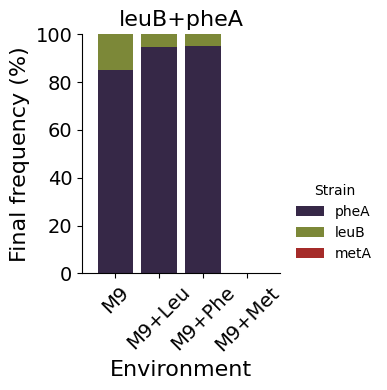

  media coculture  freq_sum
0    M9        LM     100.0
1     f        LM       0.0
2     l        LM       0.0
3     m        LM     100.0
Exporting to /content/profileX/figures/expe-constant-pairwise-freqs-LM.pdf


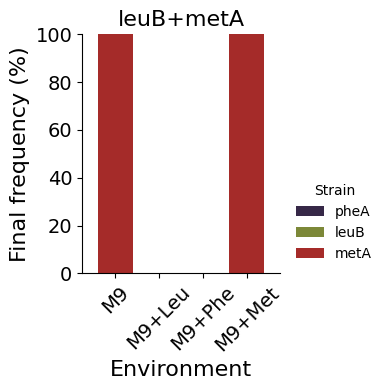

  media coculture  freq_sum
0    M9        FM       0.0
1     f        FM     100.0
2     l        FM       0.0
3     m        FM     100.0
Exporting to /content/profileX/figures/expe-constant-pairwise-freqs-FM.pdf


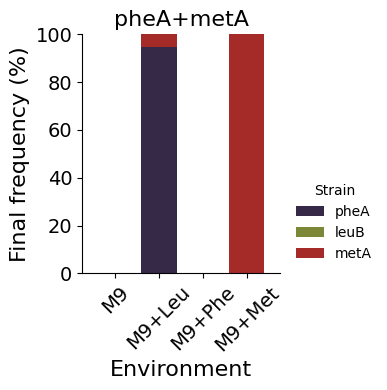

In [15]:
plot_day5_frequencies(
    df,
    media_values=["M9", "f", "l", "m"],
    cocultures=["LF"],
    day=5,
    title='leuB+pheA'
)
outfile = figures_path / f"expe-constant-pairwise-freqs-LF.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300)
plt.show()

plot_day5_frequencies(
    df,
    media_values=["M9", "f", "l", "m"],
    cocultures=["LM"],
    day=5,
    title='leuB+metA'
)
outfile = figures_path / f"expe-constant-pairwise-freqs-LM.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300)
plt.show()

plot_day5_frequencies(
    df,
    media_values=["M9", "f", "l", "m"],
    cocultures=["FM"],
    day=5,
    title='pheA+metA'
)
outfile = figures_path / f"expe-constant-pairwise-freqs-FM.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300)
plt.show()

## OD data

In [16]:
def load_od_data_csv(csv_file):
    """
    Load OD time-series data from local CSV.
    """

    import pandas as pd

    df_od = pd.read_csv(csv_file)

    # Remove fully empty rows
    df_od = df_od.dropna(how="all")

    # Clean column names
    df_od.columns = [
        str(c).strip()
        for c in df_od.columns
    ]

    # Remove empty unnamed columns
    df_od = df_od.drop(
        columns=[
            c for c in df_od.columns
            if c.startswith("Unnamed")
            and df_od[c].isna().all()
        ]
    )

    # Convert numeric columns
    numeric_cols = [
        "day",
        "time",
        "replica",
        "OD",
        "ODblank"
    ]

    for col in numeric_cols:
        if col in df_od.columns:
            df_od[col] = pd.to_numeric(
                df_od[col],
                errors="coerce"
            )

    return df_od

In [29]:

N3_OD_file = data_path / "ProfileX_data_N3_OD.csv"

df_od = load_od_data_csv(N3_OD_file)

print(df_od.head(10))
print("Shape:", df_od.shape)

   day traj well_inoculation well_OD  time  replica medio_anterior media  \
0    1    A               A1      A1    24        1            LFM   LFM   
1    1    A               A2      A2    24        2            LFM   LFM   
2    1    A               A3      A3    24        3            LFM   LFM   
3    1    A               A4      A4    24        4            LFM   LFM   
4    1    B               B1      B1    24        1             LF    LF   
5    1    B               B2      B2    24        2             LF    LF   
6    1    B               B3      B3    24        3             LF    LF   
7    1    B               B4      B4    24        4             LF    LF   
8    1    C               C1      C1    24        1             LM    LM   
9    1    C               C2      C2    24        2             LM    LM   

      OD  ODblank  
0  0.357    0.268  
1  0.357    0.268  
2  0.317    0.228  
3  0.322    0.233  
4  0.326    0.237  
5  0.328    0.239  
6  0.469    0.380  
7  

In [23]:
print(df_od.columns.tolist())

['day', 'traj', 'well_inoculation', 'well_OD', 'time', 'replica', 'medio_anterior', 'media', 'OD', 'ODblank']


In [24]:
# -----------------------------------------------------------
# PREPEND DAY 0
# -----------------------------------------------------------

OD0 = 0.12

# take all (ruta, replica) pairs from day=1 entries
day1 = df_od[df_od["day"] == 1].copy()

# clone structure for day0
day0 = day1.copy()

day0["day"] = 0
day0["time"] = 0
day0["OD"] = OD0

# optional but harmless — blanks are zero or NaN
if "ODblank" in day0.columns:
    day0["ODblank"] = 0.0

# optional: prefix_day zero is consistent
if "prefix_day" in day0.columns:
    day0["prefix_day"] = 0

# prefix is empty or stays unchanged — up to you
if "prefix" in day0.columns:
    day0["prefix"] = ""

# combine
df_od = pd.concat([day0, df_od], ignore_index=True)

# sort
if "prefix_day" in df_od.columns:
    df_od = df_od.sort_values(["day", "replica"]).reset_index(drop=True)
else:
    df_od = df_od.sort_values(["day", "replica"]).reset_index(drop=True)

print(df_od.head())

trajs = df_od['traj'].dropna().unique()
print(f"Trajectories: {trajs}")

   day traj well_inoculation well_OD  time  replica medio_anterior media  \
0    0    A               A1      A1     0        1            LFM   LFM   
1    0    B               B1      B1     0        1             LF    LF   
2    0    C               C1      C1     0        1             LM    LM   
3    0    D               D1      D1     0        1             FM    FM   
4    0    E               E1      E1     0        1             M9    M9   

     OD  ODblank  
0  0.12      0.0  
1  0.12      0.0  
2  0.12      0.0  
3  0.12      0.0  
4  0.12      0.0  
Trajectories: ['A' 'B' 'C' 'D' 'E' 'AA' 'BB' 'BC' 'BD' 'CC' 'DC' 'DD' 'CD' 'EE' 'AAA'
 'EEE' 'BBB' 'BCB' 'BDB' 'BBC' 'BCC' 'BDC' 'BBD' 'BCD' 'BDD' 'CCB' 'DCB'
 'CCC' 'DCC' 'CCD' 'DCD' 'DDB' 'CDB' 'DDC' 'CDC' 'DDD' 'CDD' 'AAAA' 'EEEE'
 'BBBB' 'BBCB' 'BBDB' 'BBCC' 'BBDC' 'BBCD' 'BBDD' 'BDBB' 'BDCB' 'BDDB'
 'BDBC' 'BDCC' 'BDDC' 'BDBD' 'BDCD' 'BDDD' 'DDBB' 'DDCB' 'DDDB' 'DDBC'
 'DDCC' 'DDDC' 'DDBD' 'DDCD' 'DDDD' 'CDBB' 'CDCB' 'CD

In [25]:
# --- Lineage utilities (do NOT modify df_od) ---

def lineage_prefixes(ruta: str):
    """Return the ordered list of ruta prefixes from day 1 .. len(ruta)."""
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def get_day_block_for_prefix(df, prefix: str, expected_day: int):
    """
    Return rows for a given ruta prefix and expected day.
    If your data are well-formed, day should equal len(prefix).
    We filter by both (ruta == prefix) and (day == expected_day) when present.
    """
    q = df[df['traj'] == prefix].copy()
    # Try to filter by expected day if the column is present.
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    # Sort for readability
    sort_cols = [c for c in ['day', 'replica', 'well_inoculation', 'well_OD'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def print_lineage(df, ruta: str):
    """
    Pretty-print the lineage for a ruta by walking through its prefixes.
    Shows each 'day' block and the rows found.
    """
    prefixes = lineage_prefixes(ruta)
    print("="*60)
    print(f" LINEAGE RECONSTRUCTION FOR: {ruta}")
    print("="*60)

    # sanity check: if 'day' exists, verify day == len(prefix)
    if 'day' in df.columns:
        mismatches = []
        for i, p in enumerate(prefixes, start=1):
            rows = df[df['traj'] == p]
            if len(rows) and not (rows['day'] == i).all():
                mismatches.append((p, i, sorted(rows['day'].dropna().unique().tolist())))
        if mismatches:
            print("\n[Warning] Day/prefix mismatches found:")
            for p, i, days in mismatches:
                print(f"  ruta '{p}' expected day {i} but found days {days}")

    # print each day block in order
    for i, p in enumerate(prefixes, start=1):
        block = get_day_block_for_prefix(df, p, expected_day=i)
        print(f"\n--- DAY {i} | ruta '{p}' ---")
        if block.empty:
            print("(no rows)")
            continue
        # choose a compact set of columns if available
        cols = [c for c in [
            'traj', 'day', 'replica', 'well_inoculation', 'well_OD',
            'media', 'medio_anterior', 'OD', 'ODblank'
        ] if c in block.columns]
        print(block[cols].to_string(index=False))

def collect_lineage_dataframe(df, ruta: str):
    """
    Return a concatenated DataFrame for the full lineage (one block per day/prefix),
    with an extra temporary column 'prefix_day' for readability. Does NOT alter df.
    """
    prefixes = lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = get_day_block_for_prefix(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            tmp['prefix_day'] = f"{p} (day {i})"
            frames.append(tmp)
    if frames:
        out = pd.concat(frames, ignore_index=True)
        # Order columns nicely if present
        ordered = [c for c in [
            'prefix_day', 'traj', 'day', 'replica', 'well_inoculation', 'well_OD',
            'media', 'medio_anterior', 'OD', 'ODblank'
        ] if c in out.columns]
        return out[ordered]
    else:
        return pd.DataFrame()


In [26]:
# --- Lineage utilities (do NOT modify df_od) ---

def lineage_prefixes(ruta: str):
    """Return the ordered list of ruta prefixes from day 1 .. len(ruta)."""
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def get_day_block_for_prefix(df, prefix: str, expected_day: int):
    """
    Return rows for a given ruta prefix and expected day.
    If your data are well-formed, day should equal len(prefix).
    We filter by both (ruta == prefix) and (day == expected_day) when present.
    """
    q = df[df['traj'] == prefix].copy()
    # Try to filter by expected day if the column is present.
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    # Sort for readability
    sort_cols = [c for c in ['day', 'replica', 'well_inoculation', 'well_OD'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def print_lineage(df, ruta: str):
    """
    Pretty-print the lineage for a ruta by walking through its prefixes.
    Shows each 'day' block and the rows found.
    """
    prefixes = lineage_prefixes(ruta)
    print("="*60)
    print(f" LINEAGE RECONSTRUCTION FOR: {ruta}")
    print("="*60)

    # sanity check: if 'day' exists, verify day == len(prefix)
    if 'day' in df.columns:
        mismatches = []
        for i, p in enumerate(prefixes, start=1):
            rows = df[df['traj'] == p]
            if len(rows) and not (rows['day'] == i).all():
                mismatches.append((p, i, sorted(rows['day'].dropna().unique().tolist())))
        if mismatches:
            print("\n[Warning] Day/prefix mismatches found:")
            for p, i, days in mismatches:
                print(f"  ruta '{p}' expected day {i} but found days {days}")

    # print each day block in order
    for i, p in enumerate(prefixes, start=1):
        block = get_day_block_for_prefix(df, p, expected_day=i)
        print(f"\n--- DAY {i} | ruta '{p}' ---")
        if block.empty:
            print("(no rows)")
            continue
        # choose a compact set of columns if available
        cols = [c for c in [
            'traj', 'day', 'replica', 'well_inoculation', 'well_OD',
            'media', 'medio_anterior', 'OD', 'ODblank'
        ] if c in block.columns]
        print(block[cols].to_string(index=False))

def collect_lineage_dataframe(df, ruta: str):
    """
    Return a concatenated DataFrame for the full lineage (one block per day/prefix),
    with an extra temporary column 'prefix_day' for readability. Does NOT alter df.
    """
    prefixes = lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = get_day_block_for_prefix(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            tmp['prefix_day'] = f"{p} (day {i})"
            frames.append(tmp)
    if frames:
        out = pd.concat(frames, ignore_index=True)
        # Order columns nicely if present
        ordered = [c for c in [
            'prefix_day', 'traj', 'day', 'replica', 'well_inoculation', 'well_OD',
            'media', 'medio_anterior', 'OD', 'ODblank'
        ] if c in out.columns]
        return out[ordered]
    else:
        return pd.DataFrame()


def _lineage_prefixes(ruta: str):
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def _get_day_block_for_prefix(df, prefix: str, expected_day: int):
    q = df[(df['traj'] == prefix)].copy()
    # If 'day' exists, filter to the expected day (prefix length)
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    # Order for readability/consistency
    sort_cols = [c for c in ['day','replica','well_inoculation','well_OD'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def build_lineage_df(df, ruta: str):
    """
    Concatenate rows for all prefixes of 'traj' (day 1..len(ruta)).
    Does not modify df. Returns a compact dataframe ready for analysis.
    """
    prefixes = _lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = _get_day_block_for_prefix(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            # Keep a readable tag per block
            tmp['prefix'] = p
            tmp['prefix_day'] = i
            frames.append(tmp)

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)

    # Nice column order if present
    ordered = [c for c in [
        'prefix', 'prefix_day', 'traj', 'day', 'replica',
        'well_inoculation', 'well_OD', 'medio_anterior', 'media',
        'OD', 'ODblank'
    ] if c in out.columns]
    # add any other columns at the end
    others = [c for c in out.columns if c not in ordered]
    out = out[ordered+others]

    # Make day/prefix_day clean ints if possible
    for c in ['day', 'prefix_day', 'replica']:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce').astype('Int64')

    return out

# ===== B) Add blank-corrected OD (in-memory only) =====

def add_od_corrected(df_lineage, clip_zero: bool = True):
    """
    Return a copy of df_lineage with an OD_corr column = OD - ODblank.
    Does not modify the input frame.
    """
    out = df_lineage.copy()
    if all(col in out.columns for col in ['OD','ODblank']):
        out['OD_corr'] = out['OD'] - out['ODblank']
        if clip_zero:
            out['OD_corr'] = out['OD_corr'].clip(lower=0)
    return out


In [27]:


def lineage_prefixes(ruta: str):
    """Return the ordered list of ruta prefixes from day 1 .. len(ruta)."""
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def get_day_block_for_prefix(df, prefix: str, expected_day: int):
    """
    Return rows for a given ruta prefix and expected day.
    If your data are well-formed, day should equal len(prefix).
    We filter by both (ruta == prefix) and (day == expected_day) when present.
    """
    col = "traj" if "traj" in df.columns else "traj"
    q = df[df[col] == prefix].copy()
    # Try to filter by expected day if the column is present.
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    # Sort for readability
    sort_cols = [c for c in ['day', 'replica', 'well_inoculation', 'well_OD'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def print_lineage(df, ruta: str):
    """
    Pretty-print the lineage for a ruta by walking through its prefixes.
    Shows each 'day' block and the rows found.
    """
    prefixes = lineage_prefixes(ruta)
    print("="*60)
    print(f" LINEAGE RECONSTRUCTION FOR: {ruta}")
    print("="*60)

    # sanity check: if 'day' exists, verify day == len(prefix)
    if 'day' in df.columns:
        mismatches = []
        for i, p in enumerate(prefixes, start=1):
            rows = df[df['traj'] == p]
            if len(rows) and not (rows['day'] == i).all():
                mismatches.append((p, i, sorted(rows['day'].dropna().unique().tolist())))
        if mismatches:
            print("\n[Warning] Day/prefix mismatches found:")
            for p, i, days in mismatches:
                print(f"  ruta '{p}' expected day {i} but found days {days}")

    # print each day block in order
    for i, p in enumerate(prefixes, start=1):
        block = get_day_block_for_prefix(df, p, expected_day=i)
        print(f"\n--- DAY {i} | ruta '{p}' ---")
        if block.empty:
            print("(no rows)")
            continue
        # choose a compact set of columns if available
        cols = [c for c in [
            'traj', 'day', 'replica', 'well_inoculation', 'well_OD',
            'media', 'medio_anterior', 'OD', 'ODblank'
        ] if c in block.columns]
        print(block[cols].to_string(index=False))

def collect_lineage_dataframe(df, ruta: str):
    """
    Return a concatenated DataFrame for the full lineage (one block per day/prefix),
    with an extra temporary column 'prefix_day' for readability. Does NOT alter df.
    """
    prefixes = lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = get_day_block_for_prefix(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            tmp['prefix_day'] = f"{p} (day {i})"
            frames.append(tmp)
    if frames:
        out = pd.concat(frames, ignore_index=True)
        # Order columns nicely if present
        ordered = [c for c in [
            'prefix_day', 'traj', 'day', 'replica', 'well_inoculation', 'well_OD',
            'media', 'medio_anterior', 'OD', 'ODblank'
        ] if c in out.columns]
        return out[ordered]
    else:
        return pd.DataFrame()


def _lineage_prefixes(ruta: str):
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def _get_day_block_for_prefix(df, prefix: str, expected_day: int):
    q = df[(df['traj'] == prefix)].copy()
    # If 'day' exists, filter to the expected day (prefix length)
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    # Order for readability/consistency
    sort_cols = [c for c in ['day','replica','well_inoculation','well_OD'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def build_lineage_df(df, ruta: str):
    """
    Concatenate rows for all prefixes of 'traj' (day 1..len(ruta)).
    Does not modify df. Returns a compact dataframe ready for analysis.
    """
    prefixes = _lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = _get_day_block_for_prefix(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            # Keep a readable tag per block
            tmp['prefix'] = p
            tmp['prefix_day'] = i
            frames.append(tmp)

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)

    # Nice column order if present
    ordered = [c for c in [
        'prefix', 'prefix_day', 'traj', 'day', 'replica',
        'well_inoculation', 'well_OD', 'medio_anterior', 'media',
        'OD', 'ODblank'
    ] if c in out.columns]
    # add any other columns at the end
    others = [c for c in out.columns if c not in ordered]
    out = out[ordered+others]

    # Make day/prefix_day clean ints if possible
    for c in ['day', 'prefix_day', 'replica']:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce').astype('Int64')

    return out

# ===== B) Add blank-corrected OD (in-memory only) =====

def add_od_corrected(df_lineage, clip_zero: bool = True):
    """
    Return a copy of df_lineage with an OD_corr column = OD - ODblank.
    Does not modify the input frame.
    """
    out = df_lineage.copy()
    if all(col in out.columns for col in ['OD','ODblank']):
        out['OD_corr'] = out['OD'] - out['ODblank']
        if clip_zero:
            out['OD_corr'] = out['OD_corr'].clip(lower=0)
    return out


# --- Minimal helpers (as before) ---
def _lineage_prefixes(ruta: str):
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def _get_day_block_for_prefix(df, prefix: str, expected_day: int):
    q = df[(df['traj'] == prefix)].copy()
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    sort_cols = [c for c in ['day','replica','well_inoculation','well_OD'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def build_lineage_df(df, ruta: str):
    prefixes = _lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = _get_day_block_for_prefix(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            tmp['prefix'] = p
            tmp['prefix_day'] = i
            frames.append(tmp)

    # ---------- IF EMPTY ----------
    if not frames:
        return pd.DataFrame()

    # ---------- CONCAT ----------
    out = pd.concat(frames, ignore_index=True)

    # ---------- ADD DAY 0 HERE ----------
    # Only if we have day 1 information (replicate structure)
    d1 = out[out["prefix_day"] == 1]
    if not d1.empty:
        d0 = d1.copy()
        d0["prefix_day"] = 0          # plot axis anchor
        d0["prefix"] = ""             # empty prefix = day0
        d0["day"] = 0                 # visible if plotted on "day"
        d0["OD"] = 0.12               # fixed day-0 OD
        if "ODblank" in d0.columns:
            d0["ODblank"] = 0.0
        # Append to the lineage
        out = pd.concat([d0, out], ignore_index=True)

    # ---------- CLEAN NUMERIC TYPES ----------
    for c in ['day','prefix_day','replica']:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce').astype('Int64')

    # ---------- SORT ----------
    if "replica" in out.columns:
        out = out.sort_values(["prefix_day","replica"]).reset_index(drop=True)
    else:
        out = out.sort_values(["prefix_day"]).reset_index(drop=True)

    return out

def add_od_corrected(df_lineage, clip_zero: bool = True):
    out = df_lineage.copy()
    if all(col in out.columns for col in ['OD','ODblank']):
        out['OD_corr'] = out['OD'] - out['ODblank']
        if clip_zero:
            out['OD_corr'] = out['OD_corr'].clip(lower=0)
    return out

# --- New: build a list of lineage dataframes ---
def build_lineages(df, rutas, corrected: bool = True):
    """
    rutas: str or list of str
    returns: list of lineage DataFrames (same order as rutas)
    """
    if isinstance(rutas, str):
        rutas = [rutas]
    out_list = []
    for r in rutas:
        lin = build_lineage_df(df, r)
        if corrected:
            lin = add_od_corrected(lin, clip_zero=True)
        lin['traj'] = r
        out_list.append(lin)
    return out_list


In [31]:
def load_frequency_table_csv(csv_file):
    """
    Load frequency / flow-cytometry table from local CSV.
    """

    import pandas as pd

    df_freq = pd.read_csv(csv_file)

    # Drop fully empty rows
    df_freq = df_freq.dropna(how="all")

    # Clean column names
    df_freq.columns = [
        str(c).strip()
        for c in df_freq.columns
    ]

    # Remove empty unnamed columns
    df_freq = df_freq.drop(
        columns=[
            c for c in df_freq.columns
            if c.startswith("Unnamed")
            and df_freq[c].isna().all()
        ]
    )

    # Numeric columns
    num_cols = [
        "plate",
        "mCherry",
        "leuB GPF",
        "metA",
        "pct_F",
        "pct_L",
        "pct_M"
    ]

    for col in num_cols:
        if col in df_freq.columns:
            df_freq[col] = pd.to_numeric(
                df_freq[col],
                errors="coerce"
            )

    # Clean string columns
    str_cols = [
        "co-culture",
        "Plate",
        "well"
    ]

    for col in str_cols:
        if col in df_freq.columns:
            df_freq[col] = (
                df_freq[col]
                .astype(str)
                .str.strip()
            )

    return df_freq

In [34]:
N3_Freq_file = data_path / "ProfileX_data_N3_Freq.csv"


df_freq = load_frequency_table_csv(N3_Freq_file)

print(df_freq.head(15))
print("Shape:", df_freq.shape)

    day traj well  blancas  mCherry  leuB GPF  metA      pct_F      pct_L  \
0     1    A   A1      548        4       142   406   0.724638  25.724638   
1     1    B   B3      434        6       315   119   1.363636  71.590909   
2     1    C   C3     1183        4       122  1061   0.336984  10.278012   
3     1    D   D1     1278       80        73  1205   5.891016   5.375552   
4     1    E   E1      155       11        76    79   6.626506  45.783133   
5     2   AA   A1     1182        0       237   945   0.000000  20.050761   
6     2   EE   E5        0        0         0     0        NaN        NaN   
7     2   BB   B1     1245      119      1149    96   8.724340  84.237537   
8     2   BC   B5      387        0       269   118   0.000000  69.509044   
9     2   BD   B9      282       47       200    82  14.285714  60.790274   
10    2   CC   C1     1414        0       166  1248   0.000000  11.739745   
11    2   BC   C5      409      121       316    93  22.830189  59.622642   

In [35]:

# --- Lineage utilities (do NOT modify df_od) ---

def lineage_prefixes(ruta: str):
    """Return the ordered list of ruta prefixes from day 1 .. len(ruta)."""
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def get_day_block_for_prefix(df, prefix: str, expected_day: int):
    """
    Return rows for a given ruta prefix and expected day.
    If your data are well-formed, day should equal len(prefix).
    We filter by both (ruta == prefix) and (day == expected_day) when present.
    """
    q = df[df['traj'] == prefix].copy()
    # Try to filter by expected day if the column is present.
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    # Sort for readability
    sort_cols = [c for c in ['day', 'replica', 'well_inoculation', 'well_OD'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def print_lineage(df, ruta: str):
    """
    Pretty-print the lineage for a ruta by walking through its prefixes.
    Shows each 'day' block and the rows found.
    """
    prefixes = lineage_prefixes(ruta)
    print("="*60)
    print(f" LINEAGE RECONSTRUCTION FOR: {ruta}")
    print("="*60)

    # sanity check: if 'day' exists, verify day == len(prefix)
    if 'day' in df.columns:
        mismatches = []
        for i, p in enumerate(prefixes, start=1):
            rows = df[df['traj'] == p]
            if len(rows) and not (rows['day'] == i).all():
                mismatches.append((p, i, sorted(rows['day'].dropna().unique().tolist())))
        if mismatches:
            print("\n[Warning] Day/prefix mismatches found:")
            for p, i, days in mismatches:
                print(f"  ruta '{p}' expected day {i} but found days {days}")

    # print each day block in order
    for i, p in enumerate(prefixes, start=1):
        block = get_day_block_for_prefix(df, p, expected_day=i)
        print(f"\n--- DAY {i} | ruta '{p}' ---")
        if block.empty:
            print("(no rows)")
            continue
        # choose a compact set of columns if available
        cols = [c for c in [
            'traj', 'day', 'replica', 'well_inoculation', 'well_OD',
            'media', 'medio_anterior', 'OD', 'ODblank'
        ] if c in block.columns]
        print(block[cols].to_string(index=False))

def collect_lineage_dataframe(df, ruta: str):
    """
    Return a concatenated DataFrame for the full lineage (one block per day/prefix),
    with an extra temporary column 'prefix_day' for readability. Does NOT alter df.
    """
    prefixes = lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = get_day_block_for_prefix(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            tmp['prefix_day'] = f"{p} (day {i})"
            frames.append(tmp)
    if frames:
        out = pd.concat(frames, ignore_index=True)
        # Order columns nicely if present
        ordered = [c for c in [
            'prefix_day', 'traj', 'day', 'replica', 'well_inoculation', 'well_OD',
            'media', 'medio_anterior', 'OD', 'ODblank'
        ] if c in out.columns]
        return out[ordered]
    else:
        return pd.DataFrame()


def _lineage_prefixes(ruta: str):
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def _get_day_block_for_prefix(df, prefix: str, expected_day: int):
    q = df[(df['traj'] == prefix)].copy()
    # If 'day' exists, filter to the expected day (prefix length)
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    # Order for readability/consistency
    sort_cols = [c for c in ['day','replica','well_inoculation','well_OD'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def build_lineage_df(df, ruta: str):
    """
    Concatenate rows for all prefixes of 'traj' (day 1..len(ruta)).
    Does not modify df. Returns a compact dataframe ready for analysis.
    """
    prefixes = _lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = _get_day_block_for_prefix(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            # Keep a readable tag per block
            tmp['prefix'] = p
            tmp['prefix_day'] = i
            frames.append(tmp)

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)

    # Nice column order if present
    ordered = [c for c in [
        'prefix', 'prefix_day', 'traj', 'day', 'replica',
        'well_inoculation', 'well_OD', 'medio_anterior', 'media',
        'OD', 'ODblank'
    ] if c in out.columns]
    # add any other columns at the end
    others = [c for c in out.columns if c not in ordered]
    out = out[ordered+others]

    # Make day/prefix_day clean ints if possible
    for c in ['day', 'prefix_day', 'replica']:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce').astype('Int64')

    return out

# ===== B) Add blank-corrected OD (in-memory only) =====

def add_od_corrected(df_lineage, clip_zero: bool = True):
    """
    Return a copy of df_lineage with an OD_corr column = OD - ODblank.
    Does not modify the input frame.
    """
    out = df_lineage.copy()
    if all(col in out.columns for col in ['OD','ODblank']):
        out['OD_corr'] = out['OD'] - out['ODblank']
        if clip_zero:
            out['OD_corr'] = out['OD_corr'].clip(lower=0)
    return out


# --- Minimal helpers (as before) ---
def _lineage_prefixes(ruta: str):
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def _get_day_block_for_prefix(df, prefix: str, expected_day: int):
    q = df[(df['traj'] == prefix)].copy()
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    sort_cols = [c for c in ['day','replica','well_inoculation','well_OD'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def build_lineage_df(df, ruta: str):
    prefixes = _lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = _get_day_block_for_prefix(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            tmp['prefix'] = p
            tmp['prefix_day'] = i
            frames.append(tmp)

    # ---------- IF EMPTY ----------
    if not frames:
        return pd.DataFrame()

    # ---------- CONCAT ----------
    out = pd.concat(frames, ignore_index=True)

    # ---------- ADD DAY 0 HERE ----------
    # Only if we have day 1 information (replicate structure)
    d1 = out[out["prefix_day"] == 1]
    if not d1.empty:
        d0 = d1.copy()
        d0["prefix_day"] = 0          # plot axis anchor
        d0["prefix"] = ""             # empty prefix = day0
        d0["day"] = 0                 # visible if plotted on "day"
        d0["OD"] = 0.12               # fixed day-0 OD
        if "ODblank" in d0.columns:
            d0["ODblank"] = 0.0
        # Append to the lineage
        out = pd.concat([d0, out], ignore_index=True)

    # ---------- CLEAN NUMERIC TYPES ----------
    for c in ['day','prefix_day','replica']:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce').astype('Int64')

    # ---------- SORT ----------
    if "replica" in out.columns:
        out = out.sort_values(["prefix_day","replica"]).reset_index(drop=True)
    else:
        out = out.sort_values(["prefix_day"]).reset_index(drop=True)

    return out

def add_od_corrected(df_lineage, clip_zero: bool = True):
    out = df_lineage.copy()
    if all(col in out.columns for col in ['OD','ODblank']):
        out['OD_corr'] = out['OD'] - out['ODblank']
        if clip_zero:
            out['OD_corr'] = out['OD_corr'].clip(lower=0)
    return out

# --- New: build a list of lineage dataframes ---
def build_lineages(df, rutas, corrected: bool = True):
    """
    rutas: str or list of str
    returns: list of lineage DataFrames (same order as rutas)
    """
    if isinstance(rutas, str):
        rutas = [rutas]
    out_list = []
    for r in rutas:
        lin = build_lineage_df(df, r)
        if corrected:
            lin = add_od_corrected(lin, clip_zero=True)
        lin['traj'] = r
        out_list.append(lin)
    return out_list


import numpy as np
import pandas as pd

def _lineage_prefixes(ruta: str):
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def _get_day_block_for_prefix_freq(df, prefix: str, expected_day: int):
    q = df[df['traj'] == prefix].copy()
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]
    sort_cols = [c for c in ['day', 'well', 'replica'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)
    return q

def build_lineage_df_freq0(df, ruta: str):
    prefixes = _lineage_prefixes(ruta)
    frames = []
    for i, p in enumerate(prefixes, start=1):
        block = _get_day_block_for_prefix_freq(df, p, expected_day=i)
        if not block.empty:
            tmp = block.copy()
            tmp['prefix'] = p
            tmp['prefix_day'] = i
            frames.append(tmp)

    # If nothing was found, return an EMPTY DataFrame (not None)
    if not frames:
        return pd.DataFrame()

    # Concatenate all days
    out = pd.concat(frames, ignore_index=True)

    # Add day 0 with equal initial percentages (100/N)
    d1 = out[out["prefix_day"] == 1]
    if not d1.empty:
        d0 = d1.copy()
        d0["prefix_day"] = 0
        d0["prefix"] = ""
        d0["day"] = 0

        comp_cols = [c for c in ["pct_F", "pct_L", "pct_M"] if c in d0.columns]
        if not comp_cols:
            comp_cols = [c for c in ["% F", "% L", "%M"] if c in d0.columns]

        if comp_cols:
            equal_val = 100.0 / len(comp_cols)
            for col in comp_cols:
                d0[col] = equal_val

        for col in ["mCherry", "leuB GPF", "metA", "TOTAL"]:
            if col in d0.columns:
                d0[col] = np.nan

        out = pd.concat([d0, out], ignore_index=True)

    # Types & sort
    for c in ['day','prefix_day','replica']:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce').astype('Int64')
    sort_cols = ['prefix_day']
    if "replica" in out.columns: sort_cols.append('replica')
    if "well" in out.columns:    sort_cols.append('well')
    out = out.sort_values(sort_cols).reset_index(drop=True)

    return out


# ---------------------------------------------
# Build lineage dataframes for ALL rutas
# ---------------------------------------------
def build_freq_lineages(df_freq, rutas):
    if isinstance(rutas, str):
        rutas = [rutas]

    out = []
    for r in rutas:
        lin = build_lineage_df_freq(df_freq, r)
        lin["traj"] = r
        out.append(lin)
    return out


In [36]:


def list_all_rutas(df):
    """All rutas seen in the table (deduped, stripped)."""
    return sorted(pd.Series(df['traj'].dropna().astype(str).str.strip().unique()).tolist())

def list_terminal_lineages(df):
    """
    Return rutas that are NOT a prefix of any longer ruta in the dataset.
    These are the terminal branches (leaves) regardless of which day they ended.
    """
    rutas = [r.strip() for r in df['traj'].dropna().astype(str).unique()]
    rutas_set = set(rutas)
    terminals = []
    for r in rutas_set:
        # r is terminal if no other ruta starts with r and is longer
        has_child = any((o != r) and o.startswith(r) and (len(o) > len(r)) for o in rutas_set)
        if not has_child:
            terminals.append(r)
    return sorted(terminals)

def lineage_max_day(df):
    """Max day observed for each ruta (useful for checks/QA)."""
    out = (df.dropna(subset=['traj'])
             .assign(ruta=lambda d: d['traj'].astype(str).str.strip())
             .groupby('traj', as_index=True)['day']
             .max()
             .sort_values())
    return out  # pd.Series: index=ruta, value=max day

# Optional: build all terminal lineage dataframes using your existing builder
def build_all_terminal_lineages(df, build_lineage_df, corrected=True, add_od_corrected=None):
    """
    Convenience wrapper that constructs a list of DataFrames for every terminal lineage.
    Requires your previously-defined build_lineage_df (and add_od_corrected if corrected=True).
    """
    terminals = list_terminal_lineages(df)
    frames = []
    for r in terminals:
        lin = build_lineage_df(df, r)
        if corrected and add_od_corrected is not None:
            lin = add_od_corrected(lin, clip_zero=True)
        lin['traj'] = r
        frames.append(lin)
    return terminals, frames


In [37]:
def plot_OD_lineages(
    lineage_frames,
    max_day=5,
    highlight_rutas=None,
    show_rutas=None,
    show_others=True,
    show_replicates=True,
    show_errorband=True,
    alpha_rep=0.35,
    alpha_band=0.25,
    agg="mean",
    label_color_map=None,
    ruta_mapping=None,
    sample_size=3
):
    if highlight_rutas is None:
        highlight_rutas = []
    if show_rutas is None:
        show_rutas = []
    if label_color_map is None:
        label_color_map = {}

    highlight_rutas = [str(x).strip() for x in highlight_rutas]
    show_rutas = [str(x).strip() for x in show_rutas]

    if agg == "mean":
        agg_fn = lambda s: s.mean()
    elif agg == "sum":
        agg_fn = lambda s: s.sum()
    else:
        raise ValueError("agg must be 'mean' or 'sum'")

    fig, ax = plt.subplots(figsize=(9.6, 4))

    for lin in lineage_frames:
        if lin.empty:
            continue

        traj = str(lin["traj"].iloc[0]).strip()
        lbl = str(ruta_label(ruta_mapping, traj)).strip()

        is_highlight = traj in highlight_rutas
        is_shown = traj in show_rutas

        if not show_others and not is_highlight and not is_shown:
            continue

        linestyle = ":" if lbl == "M9" else "-"

        if is_highlight or is_shown:
            color_key = lbl if lbl in label_color_map else traj[0]
            color = label_color_map.get(color_key, "#666666")

            lw_mean, lw_rep = 3.0 if is_highlight else 2.0, 1.5
            rep_alpha = 1.0 if is_highlight else 0.9
            label = lbl
            mean_alpha = 0.95
            band_alpha = alpha_band
        else:
            color = (0.7, 0.7, 0.7)
            lw_mean, lw_rep = 1.0, 1.0
            rep_alpha = alpha_rep
            label = None
            mean_alpha = 0.3
            band_alpha = 0.12

        if show_replicates and "replica" in lin.columns:
            for rep in sorted(lin["replica"].dropna().unique()):
                sub = lin[lin["replica"] == rep].sort_values("prefix_day")
                ax.plot(
                    sub["prefix_day"],
                    sub["OD"],
                    color=color,
                    alpha=rep_alpha,
                    linewidth=lw_rep,
                    linestyle=linestyle,
                )

        grouped = lin.groupby("prefix_day")["OD"]
        agg_values = grouped.apply(agg_fn).sort_index()
        std_values = grouped.std().reindex(agg_values.index)

        days = agg_values.index.to_numpy(float)
        mean_vals = pd.to_numeric(agg_values, errors="coerce").to_numpy(float)
        std_vals = pd.to_numeric(std_values, errors="coerce").fillna(0).to_numpy(float)

        if "replica" in lin.columns:
            n_reps = lin.groupby("prefix_day")["replica"].nunique().reindex(agg_values.index)
            n_reps = n_reps.fillna(sample_size).to_numpy(float)
        else:
            n_reps = np.repeat(sample_size, len(days))

        sem_vals = std_vals / np.sqrt(n_reps)

        if show_errorband:
            ax.fill_between(
                days,
                mean_vals - sem_vals,
                mean_vals + sem_vals,
                color=color,
                alpha=band_alpha,
                linewidth=0
            )

        ax.plot(
            days,
            mean_vals,
            color=color,
            linewidth=lw_mean,
            linestyle=linestyle,
            label=label,
            alpha=mean_alpha,
        )

    ax.set_xlabel("Time (days)", fontsize=16)
    ax.set_ylabel("Cumulative density (OD)", fontsize=16)
    ax.set_xlim(0, max_day)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=14)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        unique = dict(zip(labels, handles))
        ax.legend(
            unique.values(),
            unique.keys(),
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=11,
            frameon=False
        )

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    #plt.show()

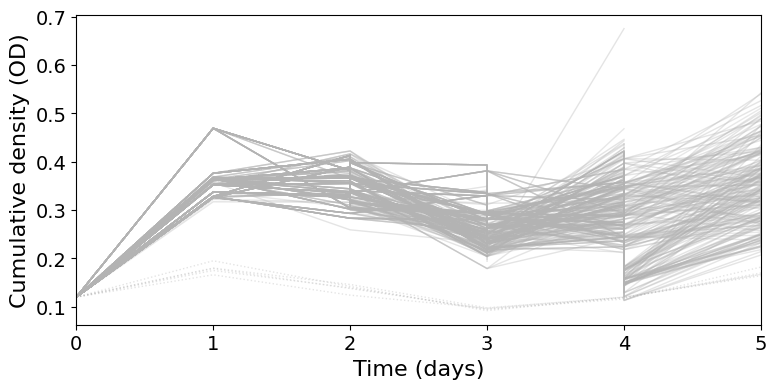

In [38]:
# List all distinct trajectories (branches)
trajs = df_od['traj'].dropna().unique()

terminal_rutas, lineage_frames = build_all_terminal_lineages(
    df_od,
    build_lineage_df=build_lineage_df,
    corrected=False,
    add_od_corrected=add_od_corrected
)


plot_OD_lineages(
    lineage_frames,
    max_day=5,
    highlight_rutas=[],
    show_replicates=True,
    show_errorband=False,
    show_others=True,
    label_color_map=LABEL_COLOR_MAP,
    ruta_mapping=ruta_mapping
)

In [39]:
def compute_lineage_stats(lineage_df):
    """
    Compute ONLY the requested statistics:
        traj
        max_day
        n_points
        OD_sum
        AUC_OD
    """

    traj = lineage_df['traj'].iloc[0] if 'traj' in lineage_df.columns else None

    # Extract values
    days = lineage_df['prefix_day'].astype(float).values
    OD_raw = lineage_df['OD'].astype(float).values

    # Compute metrics
    OD_sum = np.nansum(OD_raw)
    AUC_OD = np.trapezoid(OD_raw, x=days)

    return {
        'traj': traj,
        'max_day': int(np.nanmax(days)),
        'n_points': len(days),
        'OD_sum': OD_sum,
        'AUC_OD': AUC_OD,
    }

def compute_stats_for_all(lineage_frames):
    """
    lineage_frames: list of DataFrames, each from build_lineage_df

    Returns a pandas DataFrame with ONLY the requested statistics.
    """
    stats = []
    for lin in lineage_frames:
        if not lin.empty:
            stats.append(compute_lineage_stats(lin))

    return pd.DataFrame(stats)


In [40]:


def select_optimal_path_raw(
    lineage_frames,
    agg="mean",      # 'mean' | 'median' | 'max'
    max_day=5,
    tie_break="lex"  # how to break ties ('lex' or 'first')
):
    """
    Dynamic-programming (backward) selection of a single continuous path
    maximizing total RAW OD over days 1..max_day.

    Returns:
        path_df with rows: ['day','prefix','OD_value','score_from_here']
        plus a dict 'info' with:
            - agg_df: aggregated OD per (day,prefix)
            - total_score: score of the optimal path
    """

    # ---- 1) Collect minimal columns and concatenate ----
    keep_cols = ['traj','prefix','prefix_day','replica','OD']
    frames = []
    for lf in lineage_frames:
        if lf.empty:
            continue
        cols = [c for c in keep_cols if c in lf.columns]
        if 'OD' not in cols:
            raise ValueError("Expected raw 'OD' column in lineage frame.")
        frames.append(lf[cols].copy())
    if not frames:
        return pd.DataFrame(columns=['day','prefix','OD_value','score_from_here']), {'agg_df': pd.DataFrame(), 'total_score': np.nan}

    big = (pd.concat(frames, ignore_index=True)
             .dropna(subset=['prefix','prefix_day','OD']).copy())
    big['prefix'] = big['prefix'].astype(str).str.strip()
    big['prefix_day'] = pd.to_numeric(big['prefix_day'], errors='coerce').astype('Int64')

    # De-duplicate replicate rows that may appear across terminal lineages
    dedup_cols = [c for c in ['prefix','prefix_day','replica'] if c in big.columns]
    if dedup_cols:
        big = big.drop_duplicates(subset=dedup_cols)
    else:
        big = big.drop_duplicates(subset=['prefix','prefix_day'])

    # ---- 2) Aggregate replicates per (day,prefix) using RAW OD ----
    if   agg == 'median': fn = 'median'
    elif agg == 'max':    fn = 'max'
    else:                 fn = 'mean'

    if 'replica' in big.columns:
        agg_df = (big.groupby(['prefix_day','prefix'], as_index=False)
                    .agg(OD_value=('OD', fn), n_reps=('replica','nunique')))
    else:
        agg_df = (big.groupby(['prefix_day','prefix'], as_index=False)
                    .agg(OD_value=('OD', fn), n_reps=('OD','size')))

    # Restrict to prefixes whose string length == day (well-formed)
    agg_df = agg_df[agg_df['prefix'].str.len() == agg_df['prefix_day']]

    # Index by day for quick lookups
    by_day = {int(d): sub.copy() for d, sub in agg_df.groupby('prefix_day')}

    # Ensure we have entries for all days we’ll consider
    available_days = sorted(by_day.keys())
    if not available_days:
        return pd.DataFrame(columns=['day','prefix','OD_value','score_from_here']), {'agg_df': agg_df, 'total_score': np.nan}

    # ---- 3) DP: compute best score from day d to max_day, going backwards ----
    best_score = {}     # key: (day, prefix) -> float
    best_child = {}     # key: (day, prefix) -> child_prefix at day+1 (or None)

    for d in range(max_day, 0, -1):
        if d not in by_day:
            # no candidates at this day
            continue
        candidates = by_day[d].copy()  # columns: prefix, OD_value, n_reps
        # For each prefix at day d, compute score
        scores = []
        children = []
        for _, row in candidates.iterrows():
            pref = row['prefix']
            odv  = float(row['OD_value'])
            if d == max_day or (d+1) not in by_day:
                # terminal day for scoring
                scores.append(odv)
                children.append(None)
            else:
                # find children at day d+1 (prefixes that start with pref and len == d+1)
                next_day = by_day[d+1]
                kids = next_day[next_day['prefix'].str.startswith(pref)]
                if kids.empty:
                    # no continuation; terminal here
                    scores.append(odv)
                    children.append(None)
                else:
                    # among children, pick the one with highest best_score
                    # (if we haven't computed next day yet, we are going backwards so it should exist)
                    kid_scores = []
                    for kp in kids['prefix']:
                        kid_scores.append(best_score.get((d+1, kp), 0.0))
                    kid_scores = np.asarray(kid_scores, dtype=float)
                    # tie-break on child prefix if equal score
                    max_k = kid_scores.max()
                    kid_rows = kids[kid_scores == max_k]
                    if len(kid_rows) > 1 and tie_break == 'lex':
                        chosen_kid = kid_rows.sort_values('prefix').iloc[0]['prefix']
                    else:
                        chosen_kid = kid_rows.iloc[0]['prefix']
                    scores.append(odv+best_score.get((d+1, chosen_kid), 0.0))
                    children.append(chosen_kid)

        # store results for day d
        candidates = candidates.assign(score_from_here=scores, child=children)

        # fill best_score, best_child for each prefix at day d
        for _, r in candidates.iterrows():
            best_score[(d, r['prefix'])] = float(r['score_from_here'])
            best_child[(d, r['prefix'])] = r['child']

        # also keep back the updated table
        by_day[d] = candidates

    # ---- 4) Reconstruct optimal path starting from day 1 ----
    if 1 not in by_day or by_day[1].empty:
        return pd.DataFrame(columns=['day','prefix','OD_value','score_from_here']), {'agg_df': agg_df, 'total_score': np.nan}

    day1_tbl = by_day[1]
    # pick the day-1 prefix with maximum score_from_here (tie-break by prefix)
    max1 = day1_tbl['score_from_here'].max()
    top1 = day1_tbl[day1_tbl['score_from_here'] == max1]
    if len(top1) > 1 and tie_break == 'lex':
        start_row = top1.sort_values('prefix').iloc[0]
    else:
        start_row = top1.iloc[0]

    path_rows = []
    cur_day = 1
    cur_pref = start_row['prefix']
    total_score = float(start_row['score_from_here'])

    while True:
        row_d = by_day[cur_day]
        cur_row = row_d[row_d['prefix'] == cur_pref]
        if cur_row.empty:
            break
        cur_row = cur_row.iloc[0]
        path_rows.append({
            'day': int(cur_day),
            'prefix': cur_pref,
            'OD_value': float(cur_row['OD_value']),
            'score_from_here': float(cur_row['score_from_here'])
        })
        child = best_child.get((cur_day, cur_pref), None)
        if child is None or cur_day >= max_day:
            break
        cur_day += 1
        cur_pref = child

    path_df = pd.DataFrame(path_rows, columns=['day','prefix','OD_value','score_from_here'])
    return path_df, {'agg_df': agg_df, 'total_score': total_score}


In [41]:
stats_df = compute_stats_for_all(lineage_frames)
print(stats_df)
top=1

     traj  max_day  n_points  OD_sum  AUC_OD
0   AAAAA        5        24   6.968  1.5565
1    BBBB        4        28   8.471  1.1455
2    BBCB        4        20   5.457  1.0975
3    BBCC        4        20   5.740  1.1395
4    BBCD        4        20   5.573  1.1380
..    ...      ...       ...     ...     ...
68  DDDCD        5        24   7.208  1.5745
69  DDDDB        5        24   6.862  1.5035
70  DDDDC        5        24   6.997  1.5450
71  DDDDD        5        24   7.138  1.5940
72  EEEEE        5        24   3.284  0.6595

[73 rows x 5 columns]


In [42]:


print("\nTop 5 (OD_sum):")
top5_OD = stats_df.sort_values("OD_sum", ascending=False).head(top)
top5_OD_labels = top5_OD["traj"].tolist()
print(top5_OD_labels)


print("\nTop 5 (AUC):")
top5_AUC = stats_df.sort_values("AUC_OD", ascending=False).head(top)
top5_AUC_labels = top5_AUC["traj"].tolist()
print(top5_AUC_labels)

opt_path_df, info = select_optimal_path_raw(
    lineage_frames,
    agg="mean",   # or 'median' or 'max'
    max_day=5,
    tie_break="lex"
)
optimal_prefix = opt_path_df.iloc[-1]["prefix"]
ruta_mapping[optimal_prefix] = "Optimal"
optimal_label = ruta_label(ruta_mapping, optimal_prefix)
LABEL_COLOR_MAP["Optimal"] = "#E57373"
print(optimal_label, ":", optimal_prefix)
print(opt_path_df)




Top 5 (OD_sum):
['BDDDD']

Top 5 (AUC):
['DDBDB']
Optimal : BBDBD
   day prefix  OD_value  score_from_here
0    1      B   0.36500          1.81725
1    2     BB   0.30175          1.45225
2    3    BBD   0.29625          1.15050
3    4   BBDB   0.34375          0.85425
4    5  BBDBD   0.51050          0.51050


In [43]:
def get_constant_trajectories(lineage_frames):
    """
    Returns a list of traj labels whose entire prefix/traj is composed of one repeated letter.
    """
    constant_trajs = []

    for lin in lineage_frames:
        if lin.empty:
            continue

        traj = lin["traj"].iloc[0]
        if isinstance(traj, str) and len(traj) > 0:
            if len(set(traj)) == 1:  # all same character
                constant_trajs.append(traj)

    return constant_trajs
constant_rutas = get_constant_trajectories(lineage_frames)
print(constant_rutas)

['AAAAA', 'BBBB', 'CCC', 'DDDDD', 'EEEEE']


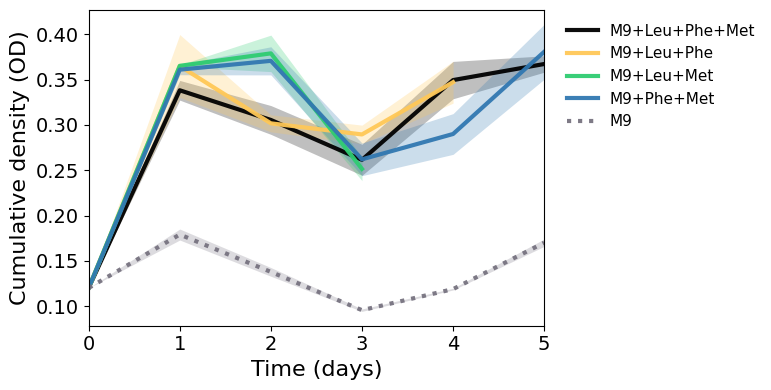

In [44]:
plot_OD_lineages(
    lineage_frames,
    max_day=5,
    highlight_rutas=CONSTANT_PATHS,
    show_replicates=False,
    show_errorband=True,
    show_others=False,
    label_color_map=LABEL_COLOR_MAP,
    ruta_mapping=ruta_mapping
)

## Frequencies

In [45]:



def _lineage_prefixes(ruta: str):
    ruta = str(ruta).strip()
    return [ruta[:i] for i in range(1, len(ruta)+1)]

def _get_day_block_for_prefix_freq(df, prefix: str, expected_day: int):
    # Select ALL trajectories that belong to this prefix family
    q = df[df['traj'].str.startswith(prefix)].copy()

    # Restrict to the correct experimental day (plate)
    if 'day' in q.columns:
        q = q[q['day'] == expected_day]

    # Sort for reproducibility
    sort_cols = [c for c in ['day', 'replica'] if c in q.columns]
    if sort_cols:
        q = q.sort_values(by=sort_cols, ignore_index=True)

    return q

def build_lineage_df_freq(df, ruta: str):
    prefixes = [ruta[:i] for i in range(1, len(ruta)+1)]

    frames = []

    for i, p in enumerate(prefixes, start=1):
        block = _get_day_block_for_prefix_freq(df, p, expected_day=i)

        if block.empty:
            continue

        tmp = block.copy()
        tmp["prefix"] = p
        tmp["prefix_day"] = i

        frames.append(tmp)

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)

    # --- add day 0 (equal frequencies) ---
    d1 = out[out["prefix_day"] == 1]

    if not d1.empty:
        d0 = d1.copy()
        d0["prefix_day"] = 0
        d0["prefix"] = ""
        d0["day"] = 0

        comp_cols = [c for c in ["pct_F", "pct_L", "pct_M"] if c in d0.columns]

        if comp_cols:
            val = 100.0 / len(comp_cols)
            for c in comp_cols:
                d0[c] = val

        out = pd.concat([d0, out], ignore_index=True)

    # Clean types
    out["prefix_day"] = pd.to_numeric(out["prefix_day"], errors="coerce").astype("Int64")

    if "replica" in out.columns:
        out["replica"] = out["replica"].astype(str).str.strip()

    out = out.sort_values(["prefix_day", "replica"]).reset_index(drop=True)

    return out


# ---------------------------------------------
# Build lineage dataframes for ALL rutas
# ---------------------------------------------
def build_freq_lineages(df_freq, rutas):
    if isinstance(rutas, str):
        rutas = [rutas]

    out = []
    for r in rutas:
        lin = build_lineage_df_freq(df_freq, r)
        lin["traj"] = r
        out.append(lin)
    return out


def print_frequency_lineage(df_freq, ruta):
    lin = build_lineage_df_freq(df_freq, ruta)
    if lin is None:
        print("build_lineage_df_freq returned None")  # should not happen now
        return
    if lin.empty:
        print(f"No frequency data for ruta {ruta}")
        return

    print(f"\n=== RECONSTRUCTED FREQUENCY TRAJECTORY FOR: {ruta} ===")
    for d in sorted(lin['prefix_day'].unique()):
        block = lin[lin['prefix_day'] == d]
        d_int = int(d)
        print(f"\n--- DAY {d_int} (ruta={ruta[:d_int]}) ---")
        cols = [c for c in ['traj','day','prefix_day','well','mCherry','leuB GPF','metA','pct_F','pct_L','pct_M'] if c in block.columns]
        print(block[cols])



# ---------- helpers ----------
def _agg_od(od_block, how="mean"):
    if od_block.empty or "OD" not in od_block.columns:
        return np.nan
    s = pd.to_numeric(od_block["OD"], errors="coerce")
    if how == "median":
        return float(s.median())
    elif how == "max":
        return float(s.max())
    else:
        return float(s.mean())
def _passes_extinction_only(freq_block, eps=0.0, missing_policy="allow"):
    """
    Return (pass_flag, info_dict).
    - Extinction if ANY strain is 0 (<= eps) in ANY replicate (counts preferred).
    - If freq_block is missing/empty:
        missing_policy = "allow"  -> pass
                         "fail"   -> fail
    """
    if freq_block is None or freq_block.empty:
        return (missing_policy == "allow"), {"criterion": "unknown", "any_extinct": None}

    # Prefer CFU counts
    count_cols = [c for c in ["mCherry", "leuB GPF", "metA"] if c in freq_block.columns]
    if count_cols:
        vals = freq_block[count_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        any_extinct = (vals.min(axis=0) <= eps).any()
        return (not any_extinct), {"criterion": "counts", "any_extinct": bool(any_extinct)}

    # Fall back to percentages
    pct_cols = [c for c in ["pct_F", "pct_L", "pct_M"] if c in freq_block.columns]
    if pct_cols:
        vals = freq_block[pct_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        any_extinct = (vals.min(axis=0) <= eps).any()
        return (not any_extinct), {"criterion": "percent", "any_extinct": bool(any_extinct)}

    # No usable columns
    return (missing_policy == "allow"), {"criterion": "unknown", "any_extinct": None}



# ---------- main selector ----------
def select_feedback_path_forward(
    od_lineage_frames,
    freq_lineage_frames,
    max_day=5,
    agg="mean",
    tie_break="lex"
):
    # ---------- gather OD ----------
    od_all = []
    for lf in od_lineage_frames:
        if lf is None or lf.empty:
            continue
        keep = [c for c in ["prefix","prefix_day","replica","OD"] if c in lf.columns]
        if not all(c in keep for c in ["prefix","prefix_day","OD"]):
            continue
        od_all.append(lf[keep].copy())
    if not od_all:
        return pd.DataFrame(columns=["day","prefix","OD_value","passed","reason"]), {"candidates": {}}

    od_all = pd.concat(od_all, ignore_index=True)
    od_all["prefix"] = od_all["prefix"].astype(str).str.strip()
    od_all["prefix_day"] = pd.to_numeric(od_all["prefix_day"], errors="coerce").astype("Int64")

    # ---------- gather FREQ (optional) ----------
    freq_all = []
    for lf in (freq_lineage_frames or []):
        if lf is None or lf.empty:
            continue
        if all(c in lf.columns for c in ["prefix","prefix_day"]):
            tmp = lf.copy()
            tmp["prefix"] = tmp["prefix"].astype(str).str.strip()
            tmp["prefix_day"] = pd.to_numeric(tmp["prefix_day"], errors="coerce").astype("Int64")
            freq_all.append(tmp)
    freq_all = pd.concat(freq_all, ignore_index=True) if freq_all else pd.DataFrame()

    freq_by_key = {}
    if not freq_all.empty:
        for (d, p), g in freq_all.groupby(["prefix_day","prefix"]):
            freq_by_key[(int(d), str(p))] = g

    od_by_day = {int(d): g.copy() for d, g in od_all.groupby("prefix_day")}

    path_rows = []
    audit = {"candidates": {}}
    current_prefix = None

    for d in range(1, max_day+1):
        if d not in od_by_day:
            break
        day_tbl = od_by_day[d].copy()

        # children filter after day 1
        if current_prefix is not None:
            day_tbl_children = day_tbl[day_tbl["prefix"].str.startswith(current_prefix)]
        else:
            day_tbl_children = day_tbl

        # reseed fallback if no children exist
        if day_tbl_children.empty:
            day_tbl_children = day_tbl.copy()   ### FIX: actually enable reseed

        if day_tbl_children.empty:
            day_tbl_children = day_tbl.copy()  # reseed

        # inside select_feedback_path_forward(...)
        # build candidate list from the correct table (children or day-1 reseed)
        src_tbl = day_tbl_children if current_prefix is not None else day_tbl

        cand = []
        for pref, block in src_tbl.groupby("prefix"):
            od_val = _agg_od(block, how=agg)
            fblock = freq_by_key.get((d, str(pref)), pd.DataFrame())
            passed, info = _passes_extinction_only(fblock, eps=0.0, missing_policy="allow")  # <-- key
            cand.append({
                "day": d,
                "prefix": str(pref),
                "OD_value": float(od_val),
                "passed": bool(passed),
                "criterion": info["criterion"],
                "any_extinct": info["any_extinct"],
            })

        cand_df = pd.DataFrame(cand).sort_values(
            ["passed","OD_value","prefix"], ascending=[False,False,True]
        )
        audit["candidates"][d] = cand_df.copy()

        keep = cand_df[cand_df["passed"]]
        if keep.empty:
            break

        best = keep.sort_values(["OD_value","prefix"], ascending=[False,True]).iloc[0]
        path_rows.append({
            "day": int(best["day"]),
            "prefix": best["prefix"],
            "OD_value": float(best["OD_value"]),
            "passed": True,
            "reason": f"{best['criterion']} (any_extinct={best['any_extinct']})"
        })
        current_prefix = best["prefix"]

    path_df = pd.DataFrame(path_rows, columns=["day","prefix","OD_value","passed","reason"])
    return path_df, audit



In [49]:
def load_frequency_data_csv(csv_file, verbose=True):

    import pandas as pd

    df = pd.read_csv(csv_file)

    # --------------------------------------------------
    # Clean dataframe
    # --------------------------------------------------

    df = df.dropna(how="all")

    df.columns = [
        str(c).strip()
        for c in df.columns
    ]

    df = df.drop(columns=[
        c for c in df.columns
        if c.startswith("Unnamed")
        and df[c].isna().all()
    ])

    # --------------------------------------------------
    # Rename legacy columns if needed
    # --------------------------------------------------

    df = df.rename(columns={
        "plate": "day",
        "well": "replica",
    })

    # --------------------------------------------------
    # Validate required columns
    # --------------------------------------------------

    required = [
        "day",
        "traj",
        "replica",
        "pct_F",
        "pct_L",
        "pct_M"
    ]

    missing = [
        c for c in required
        if c not in df.columns
    ]

    if missing:
        raise KeyError(
            f"Missing required columns: {missing}\n"
            f"Available columns:\n{df.columns.tolist()}"
        )

    # --------------------------------------------------
    # Standardize numeric columns
    # --------------------------------------------------

    numeric_cols = [
        "day",
        "mCherry",
        "leuB GPF",
        "metA",
        "pct_F",
        "pct_L",
        "pct_M",
        "TOTAL",
        "total_CFU"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    # --------------------------------------------------
    # String cleanup
    # --------------------------------------------------

    for col in ["traj", "replica"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
        )

    # --------------------------------------------------
    # Compatibility with plotting functions
    # --------------------------------------------------

    df["prefix_day"] = (
        pd.to_numeric(
            df["day"],
            errors="coerce"
        )
        .astype("Int64")
    )

    # --------------------------------------------------
    # Diagnostics
    # --------------------------------------------------

    if verbose:

        print("\nFrequency data loaded at replicate level\n")

        print(
            df[
                [
                    "day",
                    "prefix_day",
                    "traj",
                    "replica",
                    "pct_F",
                    "pct_L",
                    "pct_M"
                ]
            ].head()
        )

        print("\nReplicates per trajectory/day:\n")

        print(
            df.groupby(
                ["traj", "prefix_day"]
            )["replica"]
            .nunique()
            .head(10)
        )

        print("\nShape:", df.shape)

    return df

In [51]:
freq_file = data_path / "ProfileX_data_N3_Freq.csv"

df_freq = load_frequency_data_csv(
    freq_file,
    verbose=True
)


Frequency data loaded at replicate level

   day  prefix_day traj replica     pct_F      pct_L      pct_M
0    1           1    A      A1  0.724638  25.724638  73.550725
1    1           1    B      B3  1.363636  71.590909  27.045455
2    1           1    C      C3  0.336984  10.278012  89.385004
3    1           1    D      D1  5.891016   5.375552  88.733432
4    1           1    E      E1  6.626506  45.783133  47.590361

Replicates per trajectory/day:

traj   prefix_day
A      1             1
AA     2             1
AAA    3             1
AAAA   4             1
AAAAA  5             1
B      1             1
BB     2             1
BBB    3             1
BBD    3             1
BBDB   4             1
Name: replica, dtype: int64

Shape: (91, 15)


In [52]:
print(optimal_label, ":", optimal_prefix)
print(opt_path_df)

print_frequency_lineage(df_freq, optimal_prefix)

Optimal : BBDBD
   day prefix  OD_value  score_from_here
0    1      B   0.36500          1.81725
1    2     BB   0.30175          1.45225
2    3    BBD   0.29625          1.15050
3    4   BBDB   0.34375          0.85425
4    5  BBDBD   0.51050          0.51050

=== RECONSTRUCTED FREQUENCY TRAJECTORY FOR: BBDBD ===

--- DAY 0 (ruta=) ---
  traj  day  prefix_day  mCherry  leuB GPF  metA      pct_F      pct_L  \
0    B    0           0        6       315   119  33.333333  33.333333   

       pct_M  
0  33.333333  

--- DAY 1 (ruta=B) ---
  traj  day  prefix_day  mCherry  leuB GPF  metA     pct_F      pct_L  \
1    B    1           1        6       315   119  1.363636  71.590909   

       pct_M  
1  27.045455  

--- DAY 2 (ruta=BB) ---
  traj  day  prefix_day  mCherry  leuB GPF  metA    pct_F      pct_L     pct_M
2   BB    2           2      119      1149    96  8.72434  84.237537  7.038123

--- DAY 3 (ruta=BBD) ---
  traj  day  prefix_day  mCherry  leuB GPF  metA  pct_F      pct_L     

In [53]:
def list_all_rutas(df):
    return sorted(
        pd.Series(df["traj"].dropna().astype(str).str.strip().unique()).tolist()
    )

# OD: all rutas, no correction, keep raw OD (feedback uses raw)
od_lineage_frames_full = build_lineages(
    df_od,
    rutas=list_all_rutas(df_od),
    corrected=False
)

# Freq: all rutas
freq_lineage_frames_full = build_freq_lineages(
    df_freq,
    rutas=list_all_rutas(df_freq)
)



In [54]:

feedback_path_df, audit = select_feedback_path_forward(
    od_lineage_frames_full,
    freq_lineage_frames_full,
    max_day=5,
    agg="mean",
    tie_break="lex"
)


freq_lineages = build_freq_lineages(df_freq, terminal_rutas)  # for example


feedback_prefix = feedback_path_df.iloc[-1]["prefix"]
ruta_mapping[feedback_prefix] = "Feedback"
feedback_label = ruta_label(ruta_mapping, feedback_prefix)
LABEL_COLOR_MAP["Feedback"] = "#00FF00"


# Optional: see which candidates were excluded each day and why
for d, cand in audit["candidates"].items():
    print(f"\n=== Day {d} candidates ===")
    print(cand)


print(feedback_label, ":", feedback_prefix)
print(feedback_path_df)
print_frequency_lineage(df_freq, feedback_prefix)


=== Day 1 candidates ===
   day prefix  OD_value  passed criterion  any_extinct
2    1      C   0.36525    True    counts        False
1    1      B   0.36500    True    counts        False
3    1      D   0.36100    True    counts        False
0    1      A   0.33825    True    counts        False
4    1      E   0.17900    True    counts        False

=== Day 2 candidates ===
   day prefix  OD_value  passed criterion  any_extinct
1    2     CD   0.34375    True    counts        False
0    2     CC   0.37900   False    counts         True

=== Day 3 candidates ===
   day prefix  OD_value  passed criterion  any_extinct
1    3    CDC   0.23600    True    counts        False
0    3    CDB   0.20475    True    counts        False
2    3    CDD   0.22725   False    counts         True

=== Day 4 candidates ===
   day prefix  OD_value  passed criterion any_extinct
2    4   CDCD   0.41600    True   unknown        None
1    4   CDCC   0.39025    True   unknown        None
0    4   CDCB   0.2

In [55]:
def _component_columns_any(df_or_lin):
    """
    Detect only pct_F, pct_L, pct_M columns.
    Never look at '% F', '% L', '%M'.
    """
    comp_cols = ["pct_F", "pct_L", "pct_M"]
    return [c for c in comp_cols if c in df_or_lin.columns]

def _normalize_freq_colors(freq_colors, comp_cols):
    """
    Normalize palette for frequency components.
    Only pct_F, pct_L, pct_M are supported.
    """
    # If freq_colors is a dict, fill missing keys from defaults
    if isinstance(freq_colors, dict):
        out = {}
        for i, c in enumerate(comp_cols):
            if c in freq_colors:
                out[c] = freq_colors[c]
            else:
                out[c] = _DEFAULT_COMP_PALETTE[i % len(_DEFAULT_COMP_PALETTE)]
        return out

    # If freq_colors is list or tuple, map sequentially
    elif isinstance(freq_colors, (list, tuple, np.ndarray)):
        pal = list(freq_colors)
        # repeat palette if too short
        if len(pal) < len(comp_cols):
            need = len(comp_cols) - len(pal)
            pal = pal + pal * (need // len(pal) + 1)
        return dict(zip(comp_cols, pal[:len(comp_cols)]))

    # fallback: default palette for whatever comp_cols we have
    else:
        return dict(zip(comp_cols, _DEFAULT_COMP_PALETTE[:len(comp_cols)]))



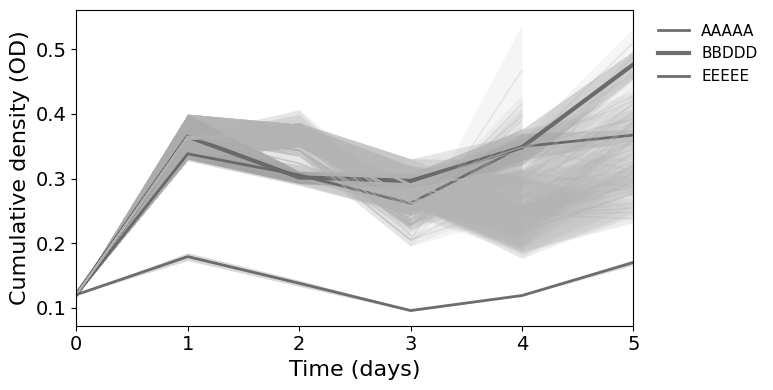

In [56]:

plot_OD_lineages(
    lineage_frames,
    max_day=5,
    highlight_rutas=[feedback_prefix],
    show_rutas=['AAAAA', 'EEEEE'],
    show_replicates=False
)


In [57]:
def plot_all_frequencies_from_lineages(
    lineage_frames,
    max_day=5,
    highlight_rutas=None,
    show_rutas=None,
    show_replicates=False,
    show_errorband=True,
    alpha_rep=0.35,
    alpha_band=0.2,
    freq_colors=None,
    highlight_colors=None,
    show_colors=None
):
    if highlight_rutas is None:
        highlight_rutas = []
    if show_rutas is None:
        show_rutas = []

    highlight_rutas = list(highlight_rutas)
    show_rutas = list(show_rutas)

    if highlight_colors is None:
        highlight_colors = ["#177E89", "#FFC857", "#FF6B6B", "#90BE6D", "#00A6A6", "#FF9F1C", "#7A9E7E"]
    if show_colors is None:
        show_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

    highlight_color_map = {}
    if highlight_rutas:
        reps = (len(highlight_rutas) + len(highlight_colors) - 1) // len(highlight_colors)
        pal = (highlight_colors * reps)[:len(highlight_rutas)]
        highlight_color_map = dict(zip(highlight_rutas, pal))

    show_color_map = {}
    if show_rutas:
        reps = (len(show_rutas) + len(show_colors) - 1) // len(show_colors)
        pal = (show_colors * reps)[:len(show_rutas)]
        show_color_map = dict(zip(show_rutas, pal))

    allowed = set(highlight_rutas) | set(show_rutas)

    fig, ax = plt.subplots(figsize=(7, 3))

    plot_title = None

    for lin in lineage_frames:
        if lin.empty:
            continue

        traj = lin["traj"].iloc[0]

        if allowed and traj not in allowed:
            continue

        if plot_title is None and traj in highlight_rutas:
            plot_title = ruta_mapping.get(traj, traj)

        comp_cols = _component_columns_any(lin)
        if not comp_cols:
            continue

        comp_color_map = _normalize_freq_colors(freq_colors, comp_cols)

        last_day = int(pd.to_numeric(lin["prefix_day"], errors="coerce").max())
        extinct = last_day < max_day
        linestyle = "-" if extinct else "-"

        if traj in highlight_color_map:
            lw_mean, lw_rep = 3.0, 1.4
            rep_alpha = 1.0
            band_alpha = alpha_band
        elif traj in show_color_map:
            lw_mean, lw_rep = 2.0, 1.2
            rep_alpha = 1.0
            band_alpha = alpha_band
        else:
            lw_mean, lw_rep = 1.5, 1.0
            rep_alpha = 0.2
            band_alpha = 0.1

        if show_replicates and "replica" in lin.columns:
            for rep in sorted(lin["replica"].dropna().unique()):
                sub = lin[lin["replica"] == rep].sort_values("prefix_day")
                for comp, comp_color in comp_color_map.items():
                    if comp in sub.columns:
                        ax.plot(
                            sub["prefix_day"],
                            sub[comp],
                            color=comp_color,
                            alpha=rep_alpha * 0.4,
                            linewidth=1.0,
                            linestyle=linestyle,
                        )

        grouped = lin.groupby("prefix_day")[comp_cols]
        mean_df = grouped.mean()
        std_df = grouped.std()
        count_df = grouped.count()
        sem_df = std_df / np.sqrt(count_df)

        for comp, comp_color in comp_color_map.items():
            if comp not in mean_df.columns:
                continue

            x = mean_df.index.to_numpy(dtype=float)
            y = mean_df[comp].to_numpy(dtype=float)
            sem = sem_df[comp].fillna(0).to_numpy(dtype=float)

            if show_errorband:
                ax.fill_between(
                    x,
                    y - sem,
                    y + sem,
                    color=comp_color,
                    alpha=band_alpha,
                    linewidth=0
                )

            ax.plot(
                x,
                y,
                color=comp_color,
                linewidth=lw_mean,
                linestyle=linestyle,
                label=(comp if traj in highlight_rutas else None),
            )

            if extinct and len(x) > 0:
                ax.scatter(
                    x[-1],
                    y[-1],
                    s=55,
                    facecolors=comp_color,
                    edgecolors=comp_color,
                    linewidths=2,
                    zorder=5
                )

    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Frequency (%)")
    ax.set_ylim(-5, 105)

    if plot_title is not None:
        ax.set_title(plot_title)

    if highlight_rutas:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))

        ax.legend(
            unique.values(),
            unique.keys(),
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=8,
            frameon=False
        )

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.xlim([0, max_day])
    # plt.show()

Exporting to /content/profileX/figures/expe-freqs-lineages-M9-Leu-Phe-Met.pdf


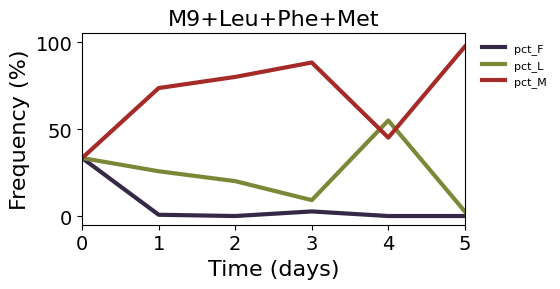

In [58]:
plot_all_frequencies_from_lineages(
    freq_lineages,
    max_day=5,
    highlight_rutas=[constant_rutas[0]],
    show_replicates=False,
    show_errorband=False,
    freq_colors=FREQ_COLORS
)

label = ruta_mapping.get(constant_rutas[0], constant_rutas[0])
safe_label = (
        label
        .replace("+", "-")
        .replace(" ", "_")
)
outfile = figures_path / f"expe-freqs-lineages-{safe_label}.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

Exporting to /content/profileX/figures/expe-freqs_lineages_ga.pdf


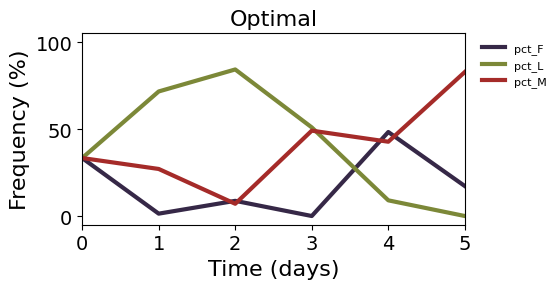

Exporting to /content/profileX/figures/expe-freqs-lineages-feedback.pdf


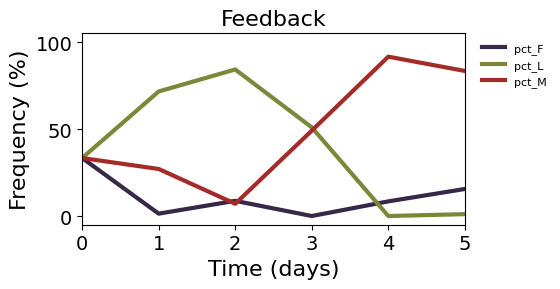

In [59]:


plot_all_frequencies_from_lineages(
    freq_lineages,
    max_day=5,
    highlight_rutas=[optimal_prefix],
    show_rutas=[],
    freq_colors=FREQ_COLORS
)
outfile = figures_path / f"expe-freqs_lineages_ga.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()


plot_all_frequencies_from_lineages(
    freq_lineages,
    max_day=5,
    highlight_rutas=[feedback_prefix],
    show_rutas=[],
    freq_colors=FREQ_COLORS
)
outfile = figures_path / f"expe-freqs-lineages-feedback.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

Exporting to /content/profileX/figures/expe-freqs-lineages-M9-Leu-Phe-Met.pdf


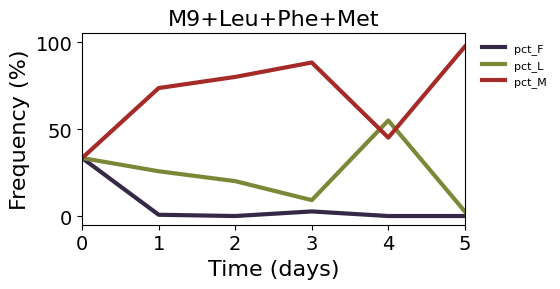

Exporting to /content/profileX/figures/expe-freqs-lineages-M9-Leu-Phe.pdf


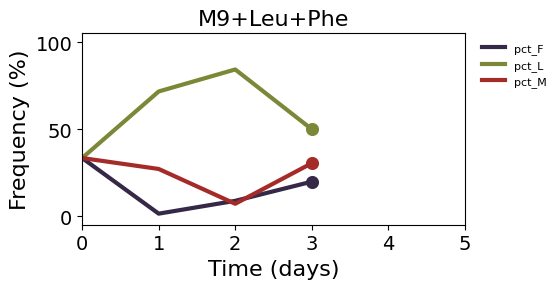

Exporting to /content/profileX/figures/expe-freqs-lineages-M9-Leu-Met.pdf


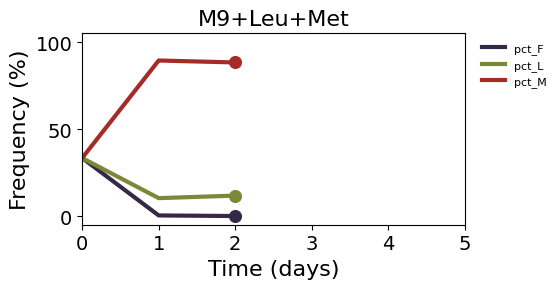

Exporting to /content/profileX/figures/expe-freqs-lineages-M9-Phe-Met.pdf


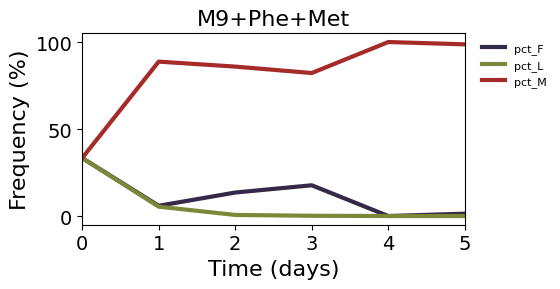

Exporting to /content/profileX/figures/expe-freqs-lineages-M9.pdf


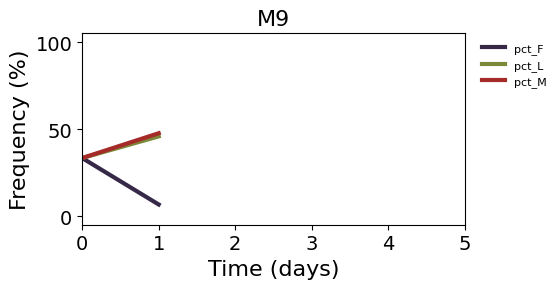

In [60]:
for cr in constant_rutas:

    plot_all_frequencies_from_lineages(
        freq_lineages,
        max_day=5,
        highlight_rutas=[cr],
        show_replicates=False,
        show_rutas=[],
        freq_colors=FREQ_COLORS
    )

    label = ruta_mapping.get(cr, cr)

    safe_label = (
        label
        .replace("+", "-")
        .replace(" ", "_")
    )

    outfile = figures_path / f"expe-freqs-lineages-{safe_label}.pdf"

    print(f"Exporting to {outfile}")

    plt.savefig(
        outfile,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [61]:
def merge_lineages(od_lin, freq_lin):
    if od_lin is None or od_lin.empty:
        return None
    if freq_lin is None or freq_lin.empty:
        return od_lin.copy()

    merged = pd.merge(
        od_lin,
        freq_lin,
        on=["traj", "prefix_day"],
        how="left",
        suffixes=("_OD", "_FREQ")
    )

    if "replica_FREQ" in merged.columns:
        merged["replica"] = merged["replica_FREQ"]
    elif "replica_OD" in merged.columns:
        merged["replica"] = merged["replica_OD"]

    return merged


merged_lineages = []

for od_lin, fq_lin in zip(lineage_frames, freq_lineages):
    merged = merge_lineages(od_lin, fq_lin)
    merged_lineages.append(merged)


In [62]:


def _detect_freq_cols(df):
    cand = ["pct_F", "pct_L", "pct_M"]
    if all(c in df.columns for c in cand):
        return cand

    return [c for c in cand if c in df.columns]
def plot_stacked_density_composition(
    df,
    max_day=5,
    mode="od_scaled",           # "od_scaled" or "percent"
    title=None,
    freq_label_map=None         # uses FREQ_LABEL_MAP if None
):
    import numpy as np
    import matplotlib.pyplot as plt

    if freq_label_map is None:
        freq_label_map = FREQ_LABEL_MAP  # assume defined globally

    # components present (uses your helper)
    comp_cols = _detect_freq_cols(df)  # -> ["pct_F","pct_L","pct_M"] subset
    if not comp_cols:
        print("[warn] No pct_* columns in dataframe.")
        return

    # labels and colors from your maps
    comp_labels = [freq_label_map.get(c, c) for c in comp_cols]
    comp_colors = [FREQ_COLORS[c] for c in comp_cols]  # <- use your palette

    # aggregate by day
    g = df.groupby("prefix_day")
    all_days = np.arange(0, max_day + 1, dtype=float)

    OD = g["OD"].mean().reindex(all_days).astype(float).fillna(0.0)
    comp = g[comp_cols].mean().reindex(all_days).astype(float).fillna(0.0)

    # choose what to stack
    if mode == "percent":
        to_stack = comp.values                         # %
        y_unit = "Frequency (%)"
    elif mode == "od_scaled":
        to_stack = (comp.values / 100.0) * OD.values[:, None]
        y_unit = "Strain density (OD)"
    else:
        raise ValueError("mode must be 'percent' or 'od_scaled'")

    # plot
    fig, ax = plt.subplots(figsize=(7, 4))
    bottom = np.zeros_like(all_days, dtype=float)

    for i, lab in enumerate(comp_labels):
        y = to_stack[:, i]
        ax.fill_between(all_days, bottom, bottom + y, color=comp_colors[i], alpha=0.65, label=lab)
        bottom += y

    if mode == "od_scaled":
        ax.plot(all_days, OD.values, color="black", linewidth=1.8, label="Total OD")

    ax.set_xlim(0, max_day)
    ax.set_ylim([0, 0.5])
    ax.set_xlabel("Day")
    ax.set_ylabel(y_unit)

    if title:
        ax.set_title(title)


    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
        frameon=False
    )
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


In [63]:
# Build OD lineages only for terminal rutas
od_lineages_terminal = build_lineages(df_od, terminal_rutas, corrected=True)

# Build FREQ lineages only for terminal rutas
freq_lineages_terminal = build_freq_lineages(df_freq, terminal_rutas)

# Merge them
merged_lineages_terminal = []
for od_lin, fq_lin in zip(od_lineages_terminal, freq_lineages_terminal):
    merged = merge_lineages(od_lin, fq_lin)
    merged_lineages_terminal.append(merged)


[skip] Feedback: no merged data


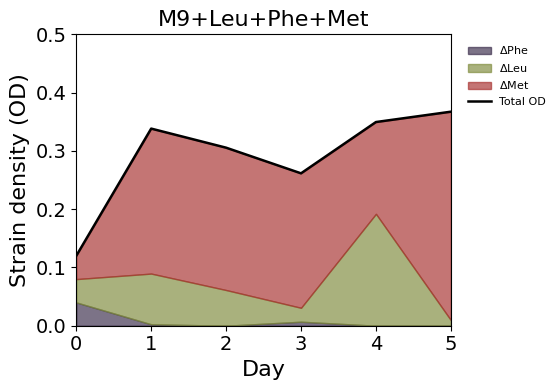

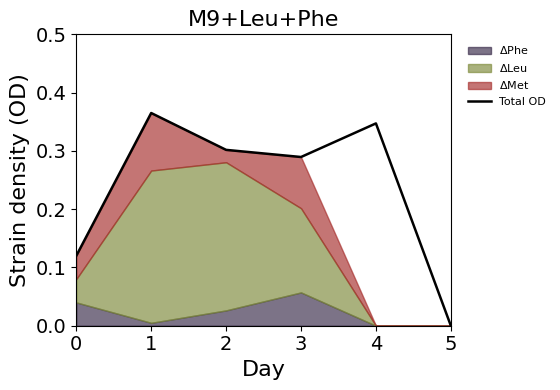

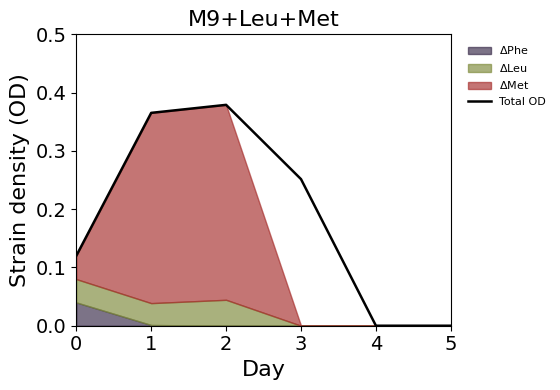

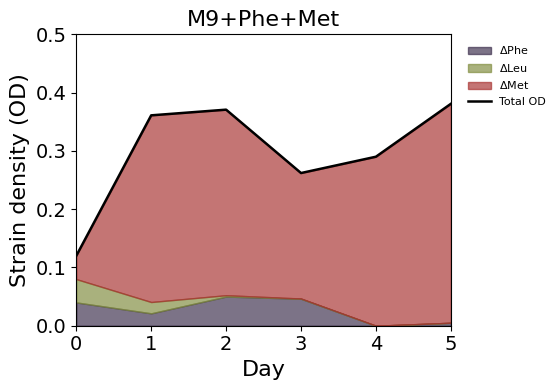

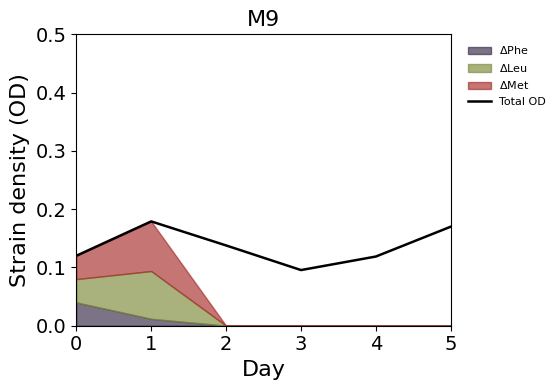

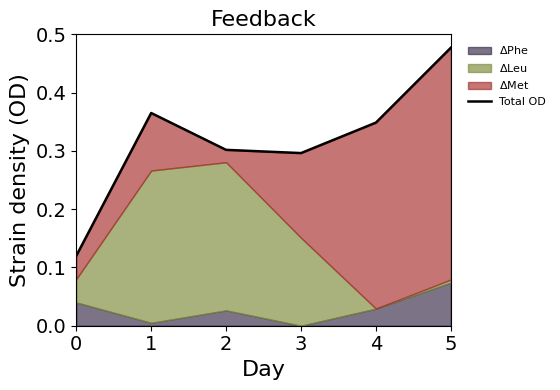

In [64]:

optimal_rutas= [optimal_label, feedback_label]
highlight_rutas = [feedback_label] + constant_rutas

def plot_selected_lineages_percent(merged_lineages, select_lineages, max_day=5):
    merged_by_traj = {
        m["traj"].iloc[0]: m
        for m in merged_lineages
        if m is not None and not m.empty and "traj" in m.columns
    }
    for traj in select_lineages:
        m = merged_by_traj.get(traj)
        if m is None or m.empty:
            print(f"[skip] {traj}: no merged data")
            continue
        plot_stacked_density_composition(
            m, max_day=max_day, mode="od_scaled",
            title=f"{ruta_label(ruta_mapping, traj)}",
            freq_label_map=FREQ_LABEL_MAP  # <- pass the map (optional, uses global otherwise)
        )

plot_selected_lineages_percent(merged_lineages, highlight_rutas, max_day=5)

plot_selected_lineages_percent(merged_lineages, [feedback_prefix], max_day=5)


### Shannon diversity

In [65]:


# -- Shannon utils (reuse from earlier) --
def _to_props(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isnan(x), 0.0, x)
    s = x.sum()
    if s <= 0:
        return np.zeros_like(x)
    return x / s

def _H_from_props(p, base="e"):
    p = np.asarray(p, dtype=float)
    p = p[(p > 0) & np.isfinite(p)]
    if p.size == 0:
        return 0.0
    if base == 2:
        return float(-(p * np.log2(p)).sum())
    return float(-(p * np.log(p)).sum())

def _detect_freq_cols_any(df):
    pref = ["pct_F","pct_L","pct_M"]
    if all(c in df.columns for c in pref): return pref
    alt  = ["% F","% L","%M"]
    if all(c in df.columns for c in alt):  return alt
    return [c for c in (pref+alt) if c in df.columns]

# -- Core per-lineage metric from merged_df (one traj) --
def fitness_from_merged(merged_df, base="e", weight="max"):
    """
    Compute:
      - fitness_value  = AUC( H(t) * w(t) ) with w(t) a density weight
      - diversity_auc  = AUC( H(t) )
      - density_auc    = AUC( density(t) )
    Time is prefix_day. Density = mean OD per day.
    weight:
      - "max": w(t) = OD(t)/max(OD)
      - float k: w(t) = OD(t)/k          (analogous to /1e9 in your GA)
      - None or 0: no weighting (returns same as diversity_auc)
    """
    if merged_df is None or merged_df.empty:
        return np.nan, np.nan, np.nan

    # per-day means
    g = merged_df.groupby("prefix_day", as_index=True)
    days = g.size().index.values.astype(float)

    # OD (density)
    if "OD" not in merged_df.columns:
        return np.nan, np.nan, np.nan
    OD = g["OD"].mean().reindex(days).astype(float).values  # aligned to days

    # frequency columns
    comp_cols = _detect_freq_cols_any(merged_df)
    if not comp_cols:
        return np.nan, np.nan, np.nan
    freq_day = g[comp_cols].mean().rename(columns={"% F":"pct_F","% L":"pct_L","%M":"pct_M"})
    comps = [c for c in ["pct_F","pct_L","pct_M"] if c in freq_day.columns]
    if not comps:
        return np.nan, np.nan, np.nan

    # H(t)
    H = []
    for d in days:
        row = freq_day.loc[d, comps].values if d in freq_day.index else np.array([np.nan, np.nan, np.nan])
        props = _to_props(row)  # from % to proportions
        H.append(_H_from_props(props, base=base))
    H = np.asarray(H, dtype=float)

    # AUCs
    diversity_auc = np.trapezoid(H, days)
    density_auc   = np.trapezoid(OD, days)

    # Weighting
    if weight == "max":
        scale = np.nanmax(OD) if np.nanmax(OD) > 0 else 1.0
        W = OD / scale
    elif isinstance(weight, (int, float)) and weight > 0:
        W = OD / float(weight)
    else:
        W = np.ones_like(OD)

    fitness_value = np.trapezoid(H * W, days)
    return fitness_value, diversity_auc, density_auc

# -- Batch over selected trajectories --
def fitness_table_for_selection(merged_lineages, select_lineages=None, base="e", weight="max"):
    """
    Returns a tidy table with fitness/diversity/density AUC per traj.
    If select_lineages is None, includes all in merged_lineages.
    """
    # build map traj -> df
    merged_by_traj = {
        m["traj"].iloc[0]: m
        for m in merged_lineages
        if m is not None and not m.empty and "traj" in m.columns
    }
    trajs = select_lineages if select_lineages is not None else list(merged_by_traj.keys())

    rows = []
    for t in trajs:
        m = merged_by_traj.get(t)
        if m is None or m.empty:
            continue
        f, aucH, aucD = fitness_from_merged(m, base=base, weight=weight)
        rows.append({"traj": t, "fitness": f, "diversity_auc": aucH, "density_auc": aucD})
    out = pd.DataFrame(rows).sort_values(["fitness","diversity_auc","density_auc"], ascending=False)
    return out


In [66]:

# --- minimal helpers reused ---
def _to_props(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isnan(x), 0.0, x)
    s = x.sum()
    if s <= 0:
        return np.zeros_like(x)
    return x / s

def _H_from_props(p, base="e"):
    p = np.asarray(p, dtype=float)
    p = p[(p > 0) & np.isfinite(p)]
    if p.size == 0:
        return 0.0
    return float(-(p * (np.log2(p) if base==2 else np.log(p))).sum())

def _detect_freq_cols_any(df):
    pref = ["pct_F","pct_L","pct_M"]
    if all(c in df.columns for c in pref): return pref
    alt  = ["% F","% L","%M"]
    if all(c in df.columns for c in alt):  return alt
    return [c for c in (pref+alt) if c in df.columns]
def shannon_diversity_by_day(freq_df, base="e"):
    req = ["pct_F", "pct_L", "pct_M"]
    for c in req:
        if c not in freq_df.columns:
            raise KeyError(f"Missing required column: {c}")
    if "prefix_day" not in freq_df.columns:
        return pd.Series(dtype=float, name="H")

    # group and mean only the required numeric columns
    g = (freq_df.groupby("prefix_day")[req]
                 .mean(numeric_only=True)
                 .sort_index())

    H = []
    for _, row in g.iterrows():
        v = row.to_numpy(dtype=float)
        v = v[np.isfinite(v)]
        v = v[v > 0]
        if v.size == 0:
            H.append(0.0)
        else:
            p = v / v.sum()
            if base == "2":
                h = -(p * np.log2(p)).sum()
            elif base == "e":
                h = -(p * np.log(p)).sum()
            else:
                h = (-(p * np.log(p)).sum()) / np.log(float(base))
            H.append(0.0 if np.isclose(h, 0.0, atol=1e-12) else float(h))
    return pd.Series(H, index=g.index, name="H")

def fitness_from_merged(merged_df, base="e", weight="max"):
    if merged_df is None or merged_df.empty or "OD" not in merged_df.columns:
        return np.nan, np.nan, np.nan
    for c in ["pct_F","pct_L","pct_M"]:
        if c not in merged_df.columns:
            raise KeyError(f"Missing required column: {c}")

    # ensure numeric index for grouping
    merged_df = merged_df.copy()
    merged_df["prefix_day"] = pd.to_numeric(merged_df["prefix_day"], errors="coerce")

    g = merged_df.groupby("prefix_day", as_index=True)

    # mean OD per day (explicit numeric selection)
    OD = g["OD"].mean()

    # mean frequencies per day (only the three numeric columns)
    freq_day = g[["pct_F","pct_L","pct_M"]].mean(numeric_only=True)

    days = OD.index.to_numpy(dtype=float)

    # Shannon per day
    H = []
    for d in days:
        row = freq_day.loc[d, ["pct_F","pct_L","pct_M"]] if d in freq_day.index else pd.Series([0,0,0], index=["pct_F","pct_L","pct_M"])
        vals = row.to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        vals = vals[vals > 0]
        if vals.size == 0:
            H.append(0.0)
        else:
            p = vals / vals.sum()
            if base == "2":
                h = -(p * np.log2(p)).sum()
            elif base == "e":
                h = -(p * np.log(p)).sum()
            else:
                h = (-(p * np.log(p)).sum()) / np.log(float(base))
            H.append(0.0 if np.isclose(h, 0.0, atol=1e-12) else float(h))
    H = np.asarray(H, dtype=float)

    diversity_auc = np.trapezoid(H, days)
    density_auc   = np.trapezoid(OD.values.astype(float), days)

    if weight == "max":
        mx = np.nanmax(OD.values)
        scale = mx if mx > 0 else 1.0
        W = OD.values.astype(float) / scale
    elif isinstance(weight, (int,float)) and weight > 0:
        W = OD.values.astype(float) / float(weight)
    else:
        W = np.ones_like(OD.values, dtype=float)

    fitness_value = np.trapezoid(H * W, days)
    return fitness_value, diversity_auc, density_auc
def fitness_table_all_terminals(merged_lineages_terminal, base="e", weight="max"):
    rows = []

    for m in merged_lineages_terminal:
        if m is None or m.empty or "traj" not in m.columns:
            continue

        for c in ["pct_F", "pct_L", "pct_M"]:
            if c not in m.columns:
                raise KeyError(f"[{m['traj'].iloc[0]}] missing required column: {c}")

        traj = m["traj"].iloc[0]

        # Original pooled calculation: DO NOT CHANGE
        f, aucH, aucD = fitness_from_merged(m, base=base, weight=weight)

        Hs = shannon_diversity_by_day(m, base=base)
        H_last = Hs.iloc[-1] if len(Hs) else np.nan

        row = {
            "traj": traj,
            "fitness": f,
            "diversity_auc": aucH,
            "density_auc": aucD,
            "shannon_diversity": H_last,
        }

        # Optional uncertainty estimate across replicas
        # This does NOT replace the pooled values above.
        if "replica" in m.columns:
            rep_rows = []

            for rep, sub in m.groupby("replica"):
                if sub is None or sub.empty:
                    continue

                f_rep, aucH_rep, aucD_rep = fitness_from_merged(
                    sub,
                    base=base,
                    weight=weight
                )

                Hs_rep = shannon_diversity_by_day(sub, base=base)
                H_last_rep = Hs_rep.iloc[-1] if len(Hs_rep) else np.nan

                rep_rows.append({
                    "fitness": f_rep,
                    "diversity_auc": aucH_rep,
                    "density_auc": aucD_rep,
                    "shannon_diversity": H_last_rep,
                })

            rep_df = pd.DataFrame(rep_rows)

            for metric in ["fitness", "diversity_auc", "density_auc", "shannon_diversity"]:
                vals = rep_df[metric].dropna()

                if len(vals) > 1:
                    row[f"{metric}_sem"] = vals.std(ddof=1) / np.sqrt(len(vals))
                    row[f"{metric}_std"] = vals.std(ddof=1)
                    row[f"{metric}_n"] = len(vals)
                else:
                    row[f"{metric}_sem"] = np.nan
                    row[f"{metric}_std"] = np.nan
                    row[f"{metric}_n"] = len(vals)
        else:
            for metric in ["fitness", "diversity_auc", "density_auc", "shannon_diversity"]:
                row[f"{metric}_sem"] = np.nan
                row[f"{metric}_std"] = np.nan
                row[f"{metric}_n"] = np.nan

        rows.append(row)

    df_out = pd.DataFrame(rows)

    if not df_out.empty:
        df_out = df_out.sort_values(
            ["fitness", "diversity_auc", "density_auc"],
            ascending=False
        ).reset_index(drop=True)

    return df_out




In [67]:
tbl_all = fitness_table_all_terminals(merged_lineages_terminal, base="e", weight="max")
print(tbl_all)


     traj   fitness  diversity_auc  density_auc  shannon_diversity  \
0   BDBBB  3.549316       4.654773     1.472125           0.949986   
1   BDBBC  3.432220       4.535897     1.431500           0.712234   
2   BDBDB  3.408957       4.427050     1.514375           1.008515   
3   BDBDD  3.245313       4.109807     1.500750           0.374028   
4   BDBDC  3.223639       4.104494     1.484125           0.363402   
..    ...       ...            ...          ...                ...   
68   CDCD  0.812886       1.415466     1.213000           0.000000   
69   CDDD  0.801857       1.267727     1.184500           0.000000   
70   CDBB  0.740152       1.131112     1.120500           0.000000   
71   CDBC  0.740152       1.131112     1.105750           0.000000   
72   CDBD  0.577651       1.131112     1.207750           0.000000   

    fitness_sem  fitness_std  fitness_n  diversity_auc_sem  diversity_auc_std  \
0      0.161172     0.360393          5           0.225700           0.504680 

### Statistics


In [68]:

try:
    from scipy.stats import mannwhitneyu, wilcoxon
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False


# ----------------------------
# Helpers
# ----------------------------
def _is_constant_traj(s: str) -> bool:
    s = str(s)
    return len(s) > 0 and len(set(s)) == 1

def _wilson_ci(k, n, alpha=0.05):
    """Wilson score CI for a proportion."""
    if n == 0:
        return (np.nan, np.nan)
    from math import sqrt
    z = 1.959963984540054 if alpha == 0.05 else 1.0  # quick default
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    half = (z * sqrt((p*(1-p) + z**2/(4*n)) / n)) / denom
    return (center - half, center + half)

def _cliffs_delta(x, y):
    """Effect size: Cliff's delta (x vs y)."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if x.size == 0 or y.size == 0:
        return np.nan
    # rank-free computation
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (x.size * y.size)

def _rank_percentile(value, arr):
    """Empirical percentile of value within arr (inclusive rank)."""
    arr = np.asarray(arr, float)
    arr = arr[~np.isnan(arr)]
    if arr.size == 0 or np.isnan(value):
        return np.nan
    return 100.0 * (arr <= value).sum() / arr.size


# ----------------------------
# Main summary
# ----------------------------
def summarize_diversity(tbl_all, optimal_traj=None, alpha=0.05):
    """
    Compute stats supporting:
      - 'constant' trajectories collapse (final-day H ~ 0)
      - optimal trajectory maintains diversity
      - many fluctuating trajectories have H > 0

    Expects columns: ['traj','shannon_diversity','density_auc','diversity_auc','fitness'].
    Returns a dict of key numbers + a tidy summary DataFrame by group.
    """
    df = tbl_all.copy()

    # annotate groups
    df["is_constant"] = df["traj"].astype(str).apply(_is_constant_traj)
    df["group"] = np.where(df["is_constant"], "constant", "fluctuating")

    # convenience slices
    H = df["shannon_diversity"].astype(float)
    H_const = df.loc[df.is_constant, "shannon_diversity"].astype(float)
    H_fluct = df.loc[~df.is_constant, "shannon_diversity"].astype(float)

    # proportions H>0 with Wilson CI
    k_const = int((H_const > 0).sum())
    n_const = int(H_const.notna().sum())
    k_fluct = int((H_fluct > 0).sum())
    n_fluct = int(H_fluct.notna().sum())
    ci_const = _wilson_ci(k_const, max(n_const, 1), alpha=alpha)
    ci_fluct = _wilson_ci(k_fluct, max(n_fluct, 1), alpha=alpha)

    # location summaries
    def _summ(x):
        x = x.dropna().astype(float)
        return dict(
            n=int(x.size),
            mean=float(x.mean()) if x.size else np.nan,
            median=float(x.median()) if x.size else np.nan,
            std=float(x.std(ddof=1)) if x.size > 1 else np.nan,
            iqr=float(np.subtract(*np.percentile(x, [75, 25]))) if x.size else np.nan
        )

    s_const = _summ(H_const)
    s_fluct = _summ(H_fluct)

    # tests vs 0 and between groups
    # one-sample Wilcoxon against 0 (robust to non-normal, but needs nonzero entries)
    p_const_vs0 = None
    p_fluct_vs0 = None
    if _HAVE_SCIPY:
        try:
            if H_const.notna().any() and (H_const != 0).any():
                p_const_vs0 = float(wilcoxon(H_const.dropna(), alternative="greater").pvalue)
            else:
                p_const_vs0 = None
        except Exception:
            p_const_vs0 = None
        try:
            if H_fluct.notna().any() and (H_fluct != 0).any():
                p_fluct_vs0 = float(wilcoxon(H_fluct.dropna(), alternative="greater").pvalue)
            else:
                p_fluct_vs0 = None
        except Exception:
            p_fluct_vs0 = None

    # Mann-Whitney (fluctuating > constant)
    p_fluct_gt_const = None
    U_stat = None
    cliffs = _cliffs_delta(H_fluct.values, H_const.values)
    if _HAVE_SCIPY and len(H_fluct.dropna()) and len(H_const.dropna()):
        try:
            U = mannwhitneyu(H_fluct.dropna(), H_const.dropna(), alternative="greater")
            p_fluct_gt_const = float(U.pvalue)
            U_stat = float(U.statistic)
        except Exception:
            p_fluct_gt_const = None
            U_stat = None

    # optimal trajectory details (if provided)
    optimal_stats = {}
    if optimal_traj is not None and optimal_traj in set(df["traj"]):
        h_opt = float(df.loc[df["traj"] == optimal_traj, "shannon_diversity"].iloc[0])
        optimal_stats = dict(
            traj=optimal_traj,
            H=h_opt,
            percentile_all=_rank_percentile(h_opt, H),
            percentile_fluct=_rank_percentile(h_opt, H_fluct)
        )
    else:
        optimal_stats = None

    # tidy table by group (means, medians, prop>0)
    summary_rows = []
    for name, subset in df.groupby("group"):
        subH = subset["shannon_diversity"].astype(float)
        k = int((subH > 0).sum())
        n = int(subH.notna().sum())
        ci = _wilson_ci(k, max(n, 1), alpha=alpha)
        summary_rows.append(dict(
            group=name,
            n=n,
            mean_H=float(subH.mean()) if n else np.nan,
            median_H=float(subH.median()) if n else np.nan,
            prop_H_gt0=(k / n) if n else np.nan,
            prop_H_gt0_CI_low=ci[0],
            prop_H_gt0_CI_high=ci[1],
        ))
    summary_df = pd.DataFrame(summary_rows)

    # collect outputs
    out = dict(
        counts=dict(
            n_total=int(len(df)),
            n_constant=n_const,
            n_fluctuating=n_fluct
        ),
        constants=dict(
            **s_const,
            prop_H_gt0=(k_const / n_const) if n_const else np.nan,
            prop_H_gt0_CI=ci_const,
            p_wilcoxon_gt0=p_const_vs0
        ),
        fluctuating=dict(
            **s_fluct,
            prop_H_gt0=(k_fluct / n_fluct) if n_fluct else np.nan,
            prop_H_gt0_CI=ci_fluct,
            p_wilcoxon_gt0=p_fluct_vs0
        ),
        between_groups=dict(
            mannwhitney_U=U_stat,
            p_fluctuating_greater_constant=p_fluct_gt_const,
            cliffs_delta=cliffs
        ),
        optimal=optimal_stats,
        summary_table=summary_df
    )
    return out


# ----------------------------
# Pretty printer (optional)
# ----------------------------
def format_results_for_text(stats, digits=3):
    """Return short, manuscript-ready bullet points from summarize_diversity()."""
    fmt = lambda x: ("nan" if x is None or (isinstance(x, float) and np.isnan(x)) else f"{x:.{digits}f}")
    const = stats["constants"]
    fluct = stats["fluctuating"]
    btw = stats["between_groups"]
    opt = stats["optimal"]

    lines = []
    # 1) constant collapse
    lines.append(
        f"Constant environments (n={stats['counts']['n_constant']}): "
        f"H_mean={fmt(const['mean'])}, median={fmt(const['median'])}, "
        f"prop(H>0)={fmt(const['prop_H_gt0'])} "
        f"[{fmt(const['prop_H_gt0_CI'][0])}, {fmt(const['prop_H_gt0_CI'][1])}] "
        f"(Wilcoxon vs 0, one-sided: p={fmt(const['p_wilcoxon_gt0'])})."
    )
    # 2) fluctuating preserve diversity
    lines.append(
        f"Fluctuating environments (n={stats['counts']['n_fluctuating']}): "
        f"H_mean={fmt(fluct['mean'])}, median={fmt(fluct['median'])}, "
        f"prop(H>0)={fmt(fluct['prop_H_gt0'])} "
        f"[{fmt(fluct['prop_H_gt0_CI'][0])}, {fmt(fluct['prop_H_gt0_CI'][1])}] "
        f"(Wilcoxon vs 0, one-sided: p={fmt(fluct['p_wilcoxon_gt0'])})."
    )
    # 3) group comparison
    lines.append(
        f"Fluctuating > Constant (Mann–Whitney one-sided): "
        f"U={fmt(btw['mannwhitney_U'])}, p={fmt(btw['p_fluctuating_greater_constant'])}, "
        f"Cliff's δ={fmt(btw['cliffs_delta'])}."
    )
    # 4) optimal trajectory (if provided)
    if opt is not None:
        lines.append(
            f"Optimal path '{opt['traj']}': H_final={fmt(opt['H'])}, "
            f"{fmt(opt['percentile_all'])}th percentile among all; "
            f"{fmt(opt['percentile_fluct'])}th percentile among fluctuating."
        )
    return lines


def summarize_diversity_compact(tbl_all, optimal_traj=None, alpha=0.05):
    """
    Wrapper: runs summarize_diversity(...) and returns a compact dict with the
    key numbers plus the original detailed object (under 'raw').
    """
    stats = summarize_diversity(tbl_all, optimal_traj=optimal_traj, alpha=alpha)

    def _fmt(x, d=3):
        if x is None: return None
        if isinstance(x, float) and (np.isnan(x) or np.isinf(x)): return None
        return round(float(x), d)

    out = {
        "n_total":            stats["counts"]["n_total"],
        "n_constant":         stats["counts"]["n_constant"],
        "n_fluctuating":      stats["counts"]["n_fluctuating"],

        # constants
        "const_mean":         _fmt(stats["constants"]["mean"]),
        "const_median":       _fmt(stats["constants"]["median"]),
        "const_prop_gt0":     _fmt(stats["constants"]["prop_H_gt0"]),
        "const_prop_gt0_CI":  tuple(_fmt(x) for x in stats["constants"]["prop_H_gt0_CI"]),
        "const_p_wil_gt0":    _fmt(stats["constants"]["p_wilcoxon_gt0"]),

        # fluctuating
        "fluct_mean":         _fmt(stats["fluctuating"]["mean"]),
        "fluct_median":       _fmt(stats["fluctuating"]["median"]),
        "fluct_prop_gt0":     _fmt(stats["fluctuating"]["prop_H_gt0"]),
        "fluct_prop_gt0_CI":  tuple(_fmt(x) for x in stats["fluctuating"]["prop_H_gt0_CI"]),
        "fluct_p_wil_gt0":    _fmt(stats["fluctuating"]["p_wilcoxon_gt0"]),

        # between groups
        "MW_U":               _fmt(stats["between_groups"]["mannwhitney_U"]),
        "MW_p_fluct_gt_const":_fmt(stats["between_groups"]["p_fluctuating_greater_constant"]),
        "cliffs_delta":       _fmt(stats["between_groups"]["cliffs_delta"]),

        # optimal (optional)
        "optimal": None if stats["optimal"] is None else {
            "traj":                 stats["optimal"]["traj"],
            "H_final":              _fmt(stats["optimal"]["H"]),
            "percentile_all":       _fmt(stats["optimal"]["percentile_all"]),
            "percentile_fluct":     _fmt(stats["optimal"]["percentile_fluct"]),
        },

        # keep full detail just in case
        "raw": stats,
    }
    return out


def print_diversity_summary(compact):
    """
    Pretty print (console) in the concise style:
    counts, constants line, fluctuating line, optional optimal line,
    and the between-groups line (kept for completeness).
    """
    def fmt(x, d=3):
        return "nan" if x is None else (f"{x:.{d}f}" if isinstance(x, float) else str(x))

    nC  = compact["n_constant"]
    nF  = compact["n_fluctuating"]

    print(f"Total trajectories: {compact['n_total']} (constant={nC}, fluctuating={nF})")

    # constants
    ciC = compact["const_prop_gt0_CI"]
    print(
        f"• Constant environments (n={nC}): "
        f"H_mean={fmt(compact['const_mean'])}, median={fmt(compact['const_median'])}, "
        f"prop(H>0)={fmt(compact['const_prop_gt0'])} "
        f"[{fmt(ciC[0])}, {fmt(ciC[1])}] "
        f"(Wilcoxon vs 0, one-sided: p={fmt(compact['const_p_wil_gt0'])})."
    )

    # fluctuating
    ciF = compact["fluct_prop_gt0_CI"]
    print(
        f"• Fluctuating environments (n={nF}): "
        f"H_mean={fmt(compact['fluct_mean'])}, median={fmt(compact['fluct_median'])}, "
        f"prop(H>0)={fmt(compact['fluct_prop_gt0'])} "
        f"[{fmt(ciF[0])}, {fmt(ciF[1])}] "
        f"(Wilcoxon vs 0, one-sided: p={fmt(compact['fluct_p_wil_gt0'])})."
    )

    # between-groups (optional — you can comment out if you’re not reporting this)
    print(
        f"• Fluctuating > Constant (Mann–Whitney one-sided): "
        f"U={fmt(compact['MW_U'])}, p={fmt(compact['MW_p_fluct_gt_const'])}, "
        f"Cliff's δ={fmt(compact['cliffs_delta'])}."
    )

    # optimal path (optional)
    if compact["optimal"] is not None:
        opt = compact["optimal"]
        print(
            f"• Best path '{opt['traj']}': H_final={fmt(opt['H_final'])}, "
            f"{fmt(opt['percentile_all'])}th percentile among all; "
            f"{fmt(opt['percentile_fluct'])}th percentile among fluctuating."
        )


In [69]:
# Compute once
comp = summarize_diversity_compact(tbl_all, optimal_traj=feedback_prefix, alpha=0.05)

# Print console-friendly bullets
print_diversity_summary(comp)



Total trajectories: 73 (constant=5, fluctuating=68)
• Constant environments (n=5): H_mean=0.038, median=0.000, prop(H>0)=0.400 [0.118, 0.769] (Wilcoxon vs 0, one-sided: p=0.250).
• Fluctuating environments (n=68): H_mean=0.246, median=0.000, prop(H>0)=0.441 [0.329, 0.559] (Wilcoxon vs 0, one-sided: p=0.000).
• Fluctuating > Constant (Mann–Whitney one-sided): U=204.000, p=0.210, Cliff's δ=0.200.
• Best path 'BBDDD': H_final=0.490, 76.712th percentile among all; 75.000th percentile among fluctuating.


## Diversity vs Density Plots

In [70]:
def _label_key_for_map(lbl: str) -> str:
    """Normalize ruta_label output to match LABEL_COLOR_MAP keys (strip spaces)."""
    return lbl.replace(" ", "")


Exporting to /content/profileX/figures/expe_shannon_density.pdf


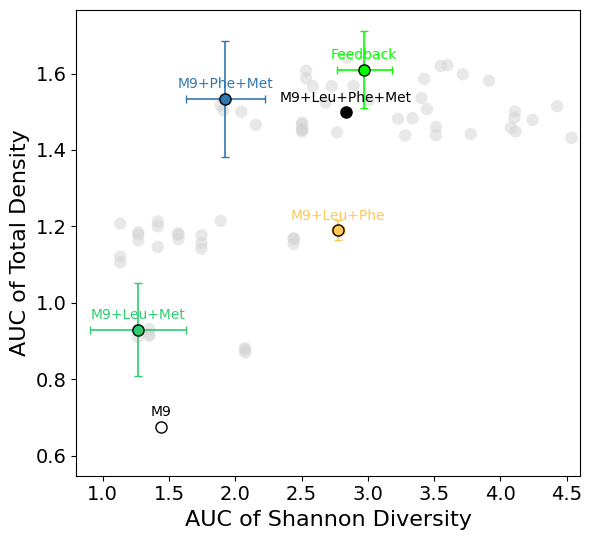

In [71]:
def plot_diversity_vs_density(
    tbl,
    highlight=None,
    highlight_colors=None,
    label_highlight=True,
    label_color_map=None
):
    import matplotlib.pyplot as plt
    import numpy as np

    if highlight is None:
        highlight = []
    highlight = list(highlight)

    if label_color_map is None:
        label_color_map = LABEL_COLOR_MAP

    fig, ax = plt.subplots(figsize=(6, 5.5))

    ax.scatter(
        tbl["diversity_auc"],
        tbl["density_auc"],
        s=80,
        c="lightgrey",
        edgecolor="none",
        alpha=0.5,
        zorder=1
    )

    for traj in highlight:
        if traj not in set(tbl["traj"]):
            continue

        row = tbl.loc[tbl["traj"] == traj].iloc[0]

        lbl = ruta_label(ruta_mapping, traj)

        key = _label_key_for_map(lbl)
        color = label_color_map.get(key, "#D62728")

        if lbl.strip() == "M9":
            facecolor = "white"
            edgecolor = "black"
            text_color = "black"
        else:
            facecolor = color
            edgecolor = "black"
            text_color = color

        x = row["diversity_auc"]
        y = row["density_auc"]

        # Use SEM if available, otherwise STD, otherwise no errorbar
        if "diversity_auc_sem" in tbl.columns:
            xerr = row["diversity_auc_sem"]
        elif "diversity_auc_std" in tbl.columns:
            xerr = row["diversity_auc_std"]
        else:
            xerr = None

        if "density_auc_sem" in tbl.columns:
            yerr = row["density_auc_sem"]
        elif "density_auc_std" in tbl.columns:
            yerr = row["density_auc_std"]
        else:
            yerr = None

        ax.errorbar(
            x,
            y,
            xerr=xerr,
            yerr=yerr,
            fmt="o",
            markersize=8,
            markerfacecolor=facecolor,
            markeredgecolor=edgecolor,
            markeredgewidth=1.0,
            ecolor=facecolor,
            elinewidth=1.2,
            capsize=3,
            zorder=5
        )
        if lbl=='BBDDD':
          lbl='Feedback'

        if label_highlight:
            ax.text(
                x,
                y + 0.02,
                lbl,
                fontsize=10,
                color=text_color,
                ha="center",
                va="bottom",
                zorder=6
            )

    ax.set_xlabel("AUC of Shannon Diversity", fontsize=16)
    ax.set_ylabel("AUC of Total Density", fontsize=16)

    ax.tick_params(axis="both", labelsize=14)

    ax.grid(alpha=0.0)
    ax.set_xlim([0.8, 4.6])

    plt.tight_layout()
    #plt.show()

plot_diversity_vs_density(
    tbl_all,
    highlight=highlight_rutas+[feedback_prefix],
    highlight_colors=LABEL_COLOR_MAP
)
outfile = figures_path / f"expe_shannon_density.pdf"
print(f"Exporting to {outfile}")
plt.savefig(outfile, dpi=300)



In [72]:
def shannon_diversity_by_day_replicates(m, base="e"):
    rows = []

    freq_cols = ["pct_F", "pct_L", "pct_M"]

    for (day, rep), sub in m.groupby(["prefix_day", "replica"]):
        row = sub[freq_cols].mean(numeric_only=True)

        vals = row.to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        vals = vals[vals > 0]

        if vals.size == 0:
            h = 0.0
        else:
            p = vals / vals.sum()
            if base == "2":
                h = -(p * np.log2(p)).sum()
            elif base == "e":
                h = -(p * np.log(p)).sum()
            else:
                h = (-(p * np.log(p)).sum()) / np.log(float(base))

        rows.append({
            "prefix_day": day,
            "replica": rep,
            "H": h
        })

    return pd.DataFrame(rows)

[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]


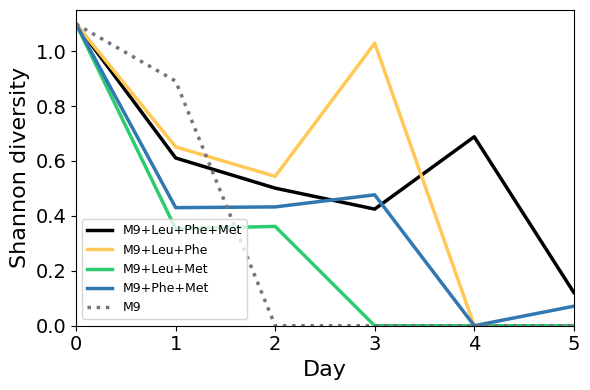

In [73]:

def plot_shannon_trajectories(
    merged_lineages,
    highlight_rutas,
    max_day=5,
    base="e",
    show_others=False,
    others_alpha=0.25,
    label_color_map=None,
    linewidth_highlight=2.5,
    linewidth_other=1.2,
    show_errorband=False,
    alpha_band=0.15
):
    """
    Plot day (prefix_day) vs Shannon diversity H for selected trajectories.
    """
    # --- Index merged_lineages by traj ---
    by_traj = {
        m["traj"].iloc[0]: m
        for m in merged_lineages
        if m is not None and not m.empty and "traj" in m.columns
    }

    # --- Label→color mapping (default from global map) ---
    if label_color_map is None:
        label_color_map = LABEL_COLOR_MAP if "LABEL_COLOR_MAP" in globals() else {}

    all_days = np.arange(0, max_day + 1, dtype=float)

    plt.figure(figsize=(6, 4))

    # ======================================================
    # grey background trajectories (optional)
    # ======================================================
    if show_others:
        for traj, m in by_traj.items():
            if traj in highlight_rutas:
                continue

            H = shannon_diversity_by_day(m, base=base)
            if H.empty:
                continue

            h = H.reindex(all_days).fillna(0.0).values

            plt.plot(
                all_days,
                h,
                color=(0.7, 0.7, 0.7),
                linewidth=linewidth_other,
                alpha=others_alpha,
            )

    # ======================================================
    # highlighted trajectories
    # ======================================================
    for traj in highlight_rutas:
        m = by_traj.get(traj)

        if m is None:
            print(f"[skip] {traj}: no merged data")
            continue

        lbl = ruta_label(ruta_mapping, traj) if "ruta_label" in globals() else traj
        key = lbl.replace(" ", "")
        color = label_color_map.get(key, "#000000")

        linestyle = ":" if lbl.strip() == "M9" else "-"

        if show_errorband and "replica" in m.columns:
            H_rep = shannon_diversity_by_day_replicates(m, base=base)

            if H_rep.empty:
                print(f"[warn] {traj}: no replicate diversity series")
                continue

            H_summary = (
                H_rep
                .groupby("prefix_day")["H"]
                .agg(["mean", "std", "count"])
                .reindex(all_days)
            )

            h = H_summary["mean"].fillna(0.0).values
            h_sem = (
                H_summary["std"] / np.sqrt(H_summary["count"])
            ).fillna(0.0).values

        else:
            H = shannon_diversity_by_day(m, base=base)

            if H.empty:
                print(f"[warn] {traj}: no diversity series")
                continue

            h = H.reindex(all_days).fillna(0.0).values
            h_sem = np.zeros_like(h)

        if show_errorband:
            print(h_sem)
            plt.fill_between(
                all_days,
                h - h_sem,
                h + h_sem,
                color=color,
                alpha=alpha_band,
                linewidth=0
            )

        plt.plot(
            all_days,
            h,
            color=color,
            linewidth=linewidth_highlight,
            linestyle=linestyle,
            label=lbl,
        )

    # ======================================================
    # formatting
    # ======================================================
    plt.xlabel("Day", fontsize=16)
    plt.ylabel("Shannon diversity", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim(0, max_day)
    plt.ylim([0, 1.15])

    if highlight_rutas:
        plt.legend(loc="lower left", fontsize=9)

    plt.tight_layout()
    plt.show()


plot_shannon_trajectories(
    merged_lineages=merged_lineages_terminal,
    highlight_rutas=constant_rutas,
    max_day=5,
    base="e",
    show_others=False,
    label_color_map=LABEL_COLOR_MAP,
    show_errorband=True
)


[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]


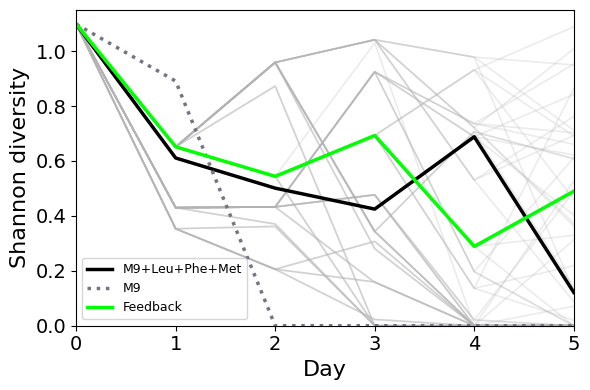

In [74]:

plot_shannon_trajectories(
    merged_lineages=merged_lineages_terminal,
    highlight_rutas=['AAAAA', 'EEEEE', feedback_prefix] ,   # your list of traj ids
    max_day=5,
    base="e",
    show_others=True,                  # set True if you want grey background lines
    label_color_map=LABEL_COLOR_MAP,     # uses your label->color mapping,
    show_errorband=True
)


[skip] Feedback: no merged data


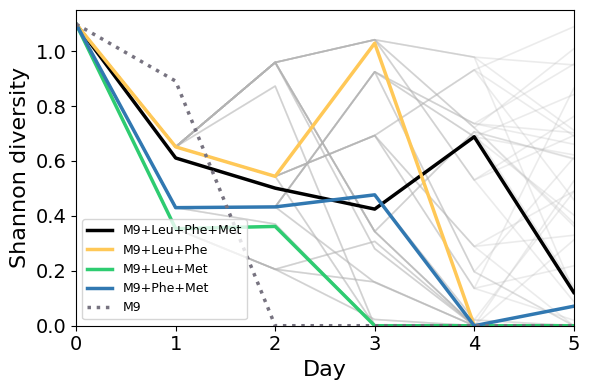

In [75]:

plot_shannon_trajectories(
    merged_lineages=merged_lineages_terminal,
    highlight_rutas=highlight_rutas,   # your list of traj ids
    max_day=5,
    base="e",
    show_others=True,                  # set True if you want grey background lines
    label_color_map=LABEL_COLOR_MAP     # uses your label->color mapping
)


## CFU trajectories

In [76]:
def plot_total_cfu_trajectories(
    merged_lineages,
    highlight_rutas,
    max_day=5,
    show_others=False,
    others_alpha=0.25,
    label_color_map=None,
    linewidth_highlight=2.5,
    linewidth_other=1.2,
):
    """
    Plot day (prefix_day) vs total_CFU for selected trajectories.
    Mirrors the logic used in plot_shannon_trajectories.
    """
    # --- Index merged_lineages by traj ---
    by_traj = {
        m["traj"].iloc[0]: m
        for m in merged_lineages
        if m is not None and not m.empty and "traj" in m.columns
    }

    # --- Label→color mapping (default from global map) ---
    if label_color_map is None:
        label_color_map = LABEL_COLOR_MAP if "LABEL_COLOR_MAP" in globals() else {}

    all_days = np.arange(0, max_day + 1, dtype=float)

    plt.figure(figsize=(6, 4))

    # ======================================================
    # grey background trajectories (optional)
    # ======================================================
    if show_others:
        for traj, m in by_traj.items():
            if traj in highlight_rutas:
                continue
            if "total_CFU" not in m.columns:
                continue

            g = m.groupby("prefix_day")["total_CFU"].mean()
            cf = g.reindex(all_days).fillna(0.0).values

            plt.plot(
                all_days,
                cf,
                color=(0.7, 0.7, 0.7),
                linewidth=linewidth_other,
                alpha=others_alpha,
            )

    # ======================================================
    # highlighted trajectories
    # ======================================================
    for traj in highlight_rutas:
        m = by_traj.get(traj)
        if m is None:
            print(f"[skip] {traj}: no merged data")
            continue
        if "total_CFU" not in m.columns:
            print(f"[warn] {traj}: no total_CFU data")
            continue

        g = m.groupby("prefix_day")["total_CFU"].mean()
        cf = g.reindex(all_days).fillna(0.0).values

        lbl = ruta_label(ruta_mapping, traj) if "ruta_label" in globals() else traj
        key = lbl.replace(" ", "")
        color = label_color_map.get(key, "#000000")

        # SPECIAL: M9 dotted
        linestyle = ":" if lbl.strip() == "M9" else "-"

        plt.plot(
            all_days,
            cf,
            color=color,
            linewidth=linewidth_highlight,
            linestyle=linestyle,
            label=lbl,
        )

    # ======================================================
    # formatting
    # ======================================================
    plt.xlabel("Day", fontsize=16)
    plt.ylabel("Total CFU", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim(0, max_day)

    # Auto-scale y based on highlighted and others
    plt.ylim(bottom=0)

    if highlight_rutas:
        plt.legend(loc="upper left", fontsize=9)

    plt.tight_layout()
    plt.show()


[skip] Feedback: no merged data


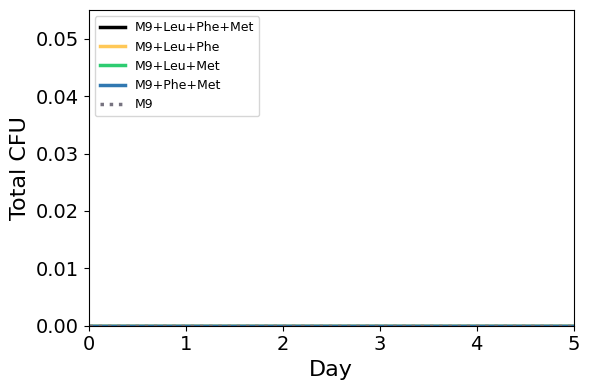

In [77]:
plot_total_cfu_trajectories(
    merged_lineages,
    highlight_rutas,
    max_day=5,
    show_others=False
)


[skip] Feedback: no merged data


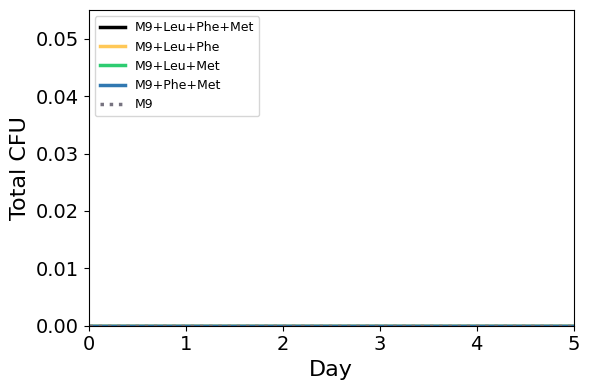

In [78]:

plot_total_cfu_trajectories(
    merged_lineages=merged_lineages_terminal,
    highlight_rutas=highlight_rutas,   # your list of traj ids
    max_day=5,
    show_others=True,                  # set True if you want grey background lines
    label_color_map=LABEL_COLOR_MAP     # uses your label->color mapping
)


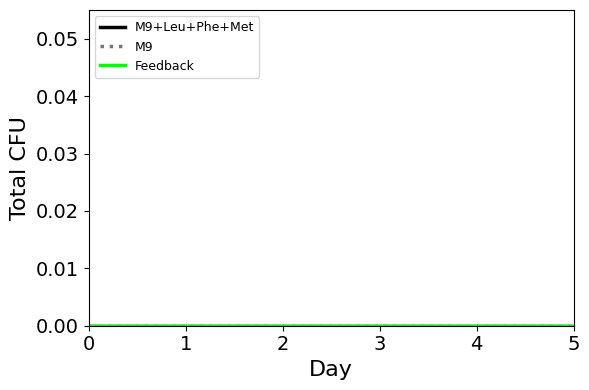

In [79]:

plot_total_cfu_trajectories(
    merged_lineages=merged_lineages_terminal,
    highlight_rutas=['AAAAA', 'EEEEE', feedback_prefix] ,
    max_day=5,
    show_others=True,
    label_color_map=LABEL_COLOR_MAP
)


In [80]:
import numpy as np
import pandas as pd

def summarize_total_cfu(
    merged_lineages,
    highlight_rutas,
    ruta_mapping,
    max_day=5,
    eps=1e-12,
    per_label=True,
    print_summary=True
):
    """
    Summarize CFU dynamics for selected trajectories.

    For each traj in highlight_rutas:
      - extinction_day: first day (>=1) where mean total_CFU <= eps
      - auc_total_cfu: trapezoid AUC of mean total_CFU over days 1..max_day
      - final_total_cfu: mean total_CFU at day=max_day (0 if missing)

    Also returns (optionally) a per-treatment aggregation using ruta_label(ruta_mapping, traj).
    """
    # Index merged_lineages by traj
    by_traj = {
        m["traj"].iloc[0]: m
        for m in merged_lineages
        if m is not None and not m.empty and "traj" in m.columns
    }

    def ruta_label(mapping, r):
        return mapping.get(r, r)

    # Collect per-trajectory stats
    rows = []
    all_days = np.arange(0, max_day + 1, dtype=float)

    for traj in highlight_rutas:
        m = by_traj.get(traj)
        label = ruta_label(ruta_mapping, traj)

        if m is None or "total_CFU" not in m.columns:
            rows.append({
                "traj": traj,
                "label": label,
                "extinction_day": np.nan,
                "auc_total_cfu": np.nan,
                "final_total_cfu": np.nan,
            })
            continue

        # Mean CFU per day; reindex to full day grid, then fill NaNs with 0 for plotting/integration
        g = m.groupby("prefix_day")["total_CFU"].mean()
        cf = g.reindex(all_days).fillna(0.0)

        # AUC on days 1..max_day (ignore any day 0 CFU for integration)
        days_int = np.arange(1, max_day + 1, dtype=float)
        cf_int = cf.reindex(days_int).values
        auc = np.trapezoid(cf_int, days_int)

        # Final CFU at day max_day
        final_cfu = float(cf.loc[max_day]) if max_day in cf.index else 0.0

        # Extinction day: first day >=1 with CFU <= eps
        extinct_mask = (cf.index >= 1) & (cf.values <= eps)
        if extinct_mask.any():
            extinction_day = int(cf.index[extinct_mask][0])
        else:
            extinction_day = np.nan  # never hits zero within window

        rows.append({
            "traj": traj,
            "label": label,
            "extinction_day": extinction_day,
            "auc_total_cfu": float(auc),
            "final_total_cfu": final_cfu,
        })

    df_traj = pd.DataFrame(rows)

    # Optional per-treatment summary
    df_label = pd.DataFrame()
    if per_label and not df_traj.empty:
        df_label = (df_traj
                    .groupby("label", as_index=False)
                    .agg(
                        n=("traj", "count"),
                        extinct_any=("extinction_day", lambda s: int(s.notna().any())),
                        extinct_prop=("extinction_day", lambda s: float(s.notna().mean())),
                        auc_mean=("auc_total_cfu", "mean"),
                        auc_median=("auc_total_cfu", "median"),
                        final_mean=("final_total_cfu", "mean"),
                        final_median=("final_total_cfu", "median"),
                    )
                   )

    if print_summary:
        # Human-readable printout
        print("\n=== CFU Summary per Trajectory ===")
        for _, r in df_traj.iterrows():
            ext_str = ("never (≤%d days)" % max_day) if pd.isna(r["extinction_day"]) else int(r["extinction_day"])
            print(f"- {r['traj']} [{r['label']}]: "
                  f"Extinction day = {ext_str}; "
                  f"AUC(total_CFU) = {r['auc_total_cfu']:.3e}; "
                  f"Final total_CFU (day {max_day}) = {r['final_total_cfu']:.3e}")

        if per_label and not df_label.empty:
            print("\n=== CFU Summary per Treatment ===")
            for _, r in df_label.iterrows():
                print(f"- {r['label']}: n={int(r['n'])}, "
                      f"any extinct={bool(r['extinct_any'])}, "
                      f"prop extinct={r['extinct_prop']:.2f}, "
                      f"AUC mean/median = {r['auc_mean']:.3e} / {r['auc_median']:.3e}, "
                      f"Final CFU mean/median = {r['final_mean']:.3e} / {r['final_median']:.3e}")

    return df_traj, df_label


In [81]:
df_traj, df_label = summarize_total_cfu(
    merged_lineages=merged_lineages,
    highlight_rutas=highlight_rutas,
    ruta_mapping=ruta_mapping,
    max_day=5,
    per_label=True,
    print_summary=True
)



=== CFU Summary per Trajectory ===
- Feedback [Feedback]: Extinction day = never (≤5 days); AUC(total_CFU) = nan; Final total_CFU (day 5) = nan
- AAAAA [M9+Leu+Phe+Met]: Extinction day = 1; AUC(total_CFU) = 0.000e+00; Final total_CFU (day 5) = 0.000e+00
- BBBB [M9+Leu+Phe]: Extinction day = 1; AUC(total_CFU) = 0.000e+00; Final total_CFU (day 5) = 0.000e+00
- CCC [M9+Leu+Met]: Extinction day = 1; AUC(total_CFU) = 0.000e+00; Final total_CFU (day 5) = 0.000e+00
- DDDDD [M9+Phe+Met]: Extinction day = 1; AUC(total_CFU) = 0.000e+00; Final total_CFU (day 5) = 0.000e+00
- EEEEE [M9]: Extinction day = 1; AUC(total_CFU) = 0.000e+00; Final total_CFU (day 5) = 0.000e+00

=== CFU Summary per Treatment ===
- Feedback: n=1, any extinct=False, prop extinct=0.00, AUC mean/median = nan / nan, Final CFU mean/median = nan / nan
- M9: n=1, any extinct=True, prop extinct=1.00, AUC mean/median = 0.000e+00 / 0.000e+00, Final CFU mean/median = 0.000e+00 / 0.000e+00
- M9+Leu+Met: n=1, any extinct=True, prop ex

## Constant environments

In [82]:
# Constant environments present in the experiment
constant_order_preferred = ["AAAAA", "BBBB", "CCC", "DDDDD", "EEEEE"]

available_trajs = {
    m["traj"].iloc[0]
    for m in merged_lineages
    if m is not None and not m.empty and "traj" in m.columns
}

constant_highlight_rutas = [
    r for r in constant_order_preferred
    if r in available_trajs
]

print("Constant trajectories found:")
for r in constant_highlight_rutas:
    print(f"  {r} -> {ruta_label(ruta_mapping, r)}")



Constant trajectories found:
  AAAAA -> M9+Leu+Phe+Met
  BBBB -> M9+Leu+Phe
  CCC -> M9+Leu+Met
  DDDDD -> M9+Phe+Met
  EEEEE -> M9


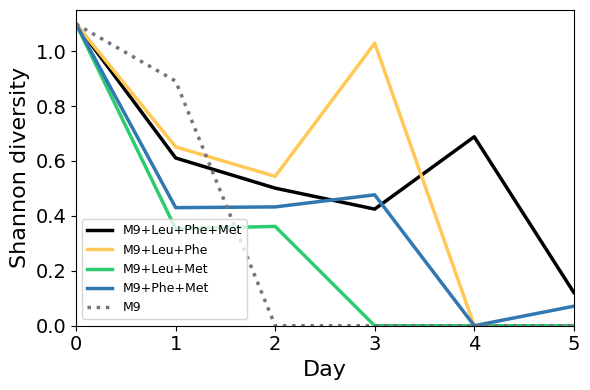

In [83]:
# Panel A: Shannon diversity vs time for all constant environments

plot_shannon_trajectories(
    merged_lineages=merged_lineages_terminal,
    highlight_rutas=constant_highlight_rutas,
    max_day=5,
    base="e",
    show_others=False,
    label_color_map=LABEL_COLOR_MAP
)

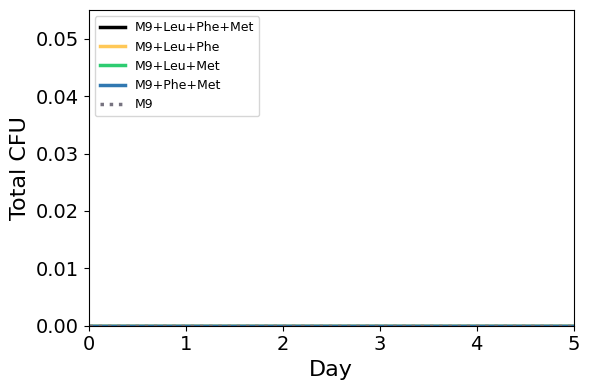

In [84]:
# Panel B: Total CFU vs time for all constant environments

plot_total_cfu_trajectories(
    merged_lineages=merged_lineages,
    highlight_rutas=constant_highlight_rutas,
    max_day=5,
    show_others=False,
    label_color_map=LABEL_COLOR_MAP
)

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_relative_abundance_constant_envs(
    merged_lineages,
    highlight_rutas,
    ruta_mapping,
    max_day=5,
    figsize_per_panel=(3.2, 2.6),
    linewidth=2.0
):
    """
    Panel C:
    Relative abundance vs time for each constant environment.
    Uses pct_F, pct_L, pct_M from merged_lineages.
    """

    # Display labels and colors
    abundance_cols = ["pct_L", "pct_F", "pct_M"]
    label_map = {
        "pct_L": "leuB",
        "pct_F": "pheA",
        "pct_M": "metA",
    }
    color_map = {
        "pct_L": "#5DA5DA",  # leuB
        "pct_F": "#F17CB0",  # pheA
        "pct_M": "#4D4D4D",  # metA
    }

    by_traj = {
        m["traj"].iloc[0]: m
        for m in merged_lineages
        if m is not None and not m.empty and "traj" in m.columns
    }

    n = len(highlight_rutas)
    if n == 0:
        print("No trajectories to plot.")
        return

    fig, axes = plt.subplots(
        1, n,
        figsize=(figsize_per_panel[0] * n, figsize_per_panel[1]),
        sharey=True
    )

    if n == 1:
        axes = [axes]

    all_days = np.arange(0, max_day + 1, dtype=float)

    for ax, traj in zip(axes, highlight_rutas):
        m = by_traj.get(traj)
        label = ruta_label(ruta_mapping, traj)

        if m is None:
            ax.set_title(label)
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_axis_off()
            continue

        cols = [c for c in abundance_cols if c in m.columns]
        if len(cols) == 0:
            ax.set_title(label)
            ax.text(0.5, 0.5, "No abundance columns", ha="center", va="center")
            ax.set_axis_off()
            continue

        tmp = m[["prefix_day"] + cols].copy()
        for c in cols:
            tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

        # mean abundance per day
        g = tmp.groupby("prefix_day", as_index=True)[cols].mean()
        g = g.reindex(all_days)

        # if values are percentages (0-100), convert to fractions (0-1)
        if np.nanmax(g.values) > 1.5:
            g = g / 100.0

        # plot directly; these are already relative abundances
        for c in cols:
            ax.plot(
                all_days,
                g[c].values,
                label=label_map[c],
                color=color_map[c],
                linewidth=linewidth
            )

        ax.set_title(label, fontsize=10)
        ax.set_xlim(0, max_day)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Day", fontsize=10)
        ax.tick_params(axis="both", labelsize=9)

    axes[0].set_ylabel("Relative abundance", fontsize=10)

    handles, labels = axes[0].get_legend_handles_labels()
    if len(labels) > 0:
        fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False)
        fig.tight_layout(rect=[0, 0, 1, 0.88])
    else:
        fig.tight_layout()

    plt.show()

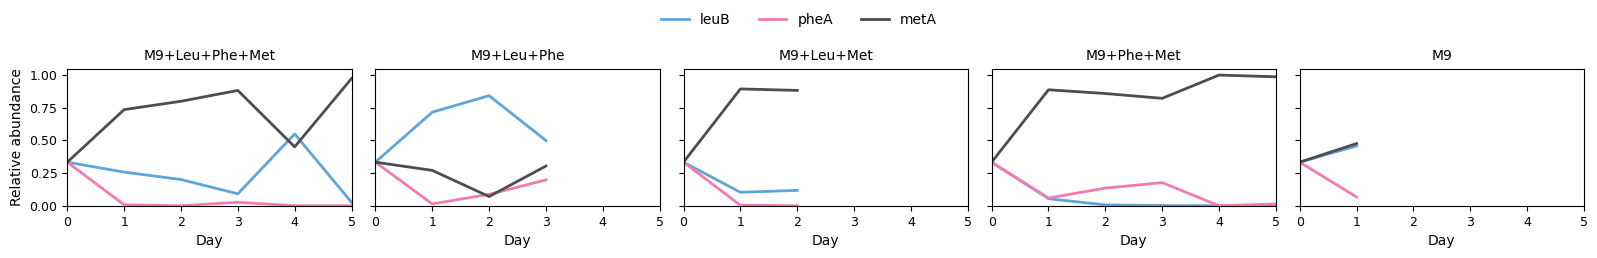

In [86]:
# Relative abundances vs time for all constant environments

plot_relative_abundance_constant_envs(
    merged_lineages=merged_lineages,
    highlight_rutas=constant_highlight_rutas,
    ruta_mapping=ruta_mapping,
    max_day=5
)

In [87]:


def summarize_dominance(
    merged_lineages,
    highlight_rutas,
    ruta_mapping,
    strain_cols=("leuB", "pheA", "metA"),
    max_day=5
):
    by_traj = {
        m["traj"].iloc[0]: m
        for m in merged_lineages
        if m is not None and not m.empty and "traj" in m.columns
    }

    results = []

    for traj in highlight_rutas:
        m = by_traj.get(traj)
        label = ruta_mapping.get(traj, traj)

        if m is None:
            continue

        cols = [c for c in strain_cols if c in m.columns]
        if len(cols) == 0:
            print(f"[skip] {traj}: none of {strain_cols} found")
            continue

        tmp = m[["prefix_day"] + cols].copy()
        for c in cols:
            tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

        g = tmp.groupby("prefix_day", as_index=True)[cols].mean()
        totals = g.sum(axis=1)

        rel = g.div(totals.replace(0, np.nan), axis=0)

        dominant = rel.idxmax(axis=1)
        dom_frac = rel.max(axis=1)

        if max_day in rel.index:
            final_dominant = dominant.loc[max_day]
            final_fraction = float(dom_frac.loc[max_day]) if pd.notna(dom_frac.loc[max_day]) else np.nan
        else:
            final_dominant = np.nan
            final_fraction = np.nan

        row = {
            "traj": traj,
            "label": label,
            "final_dominant": final_dominant,
            "final_fraction": final_fraction,
        }

        for day in sorted(rel.index):
            row[f"day{int(day)}_dominant"] = dominant.loc[day] if pd.notna(dominant.loc[day]) else np.nan
            row[f"day{int(day)}_fraction"] = float(dom_frac.loc[day]) if pd.notna(dom_frac.loc[day]) else np.nan

        results.append(row)

    return pd.DataFrame(results)

df_dom = summarize_dominance(
    merged_lineages=merged_lineages,
    highlight_rutas=highlight_rutas,
    ruta_mapping=ruta_mapping,
    strain_cols=("leuB", "pheA", "metA"),
    max_day=5
)
print(df_dom)

    traj           label final_dominant  final_fraction day0_dominant  \
0  AAAAA  M9+Leu+Phe+Met           metA             1.0          metA   
1   BBBB      M9+Leu+Phe            NaN             NaN          metA   
2    CCC      M9+Leu+Met            NaN             NaN          metA   
3  DDDDD      M9+Phe+Met           metA             1.0          metA   
4  EEEEE              M9            NaN             NaN          metA   

   day0_fraction day1_dominant  day1_fraction day2_dominant  day2_fraction  \
0            1.0          metA            1.0          metA            1.0   
1            1.0          metA            1.0          metA            1.0   
2            1.0          metA            1.0          metA            1.0   
3            1.0          metA            1.0          metA            1.0   
4            1.0          metA            1.0           NaN            NaN   

  day3_dominant  day3_fraction day4_dominant  day4_fraction day5_dominant  \
0          metA

/tmp/ipykernel_58557/1493963439.py:37: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = rel.idxmax(axis=1)
/tmp/ipykernel_58557/1493963439.py:37: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = rel.idxmax(axis=1)
/tmp/ipykernel_58557/1493963439.py:37: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  dominant = rel.idxmax(axis=1)


In [88]:


def summarize_strain_loss_times(
    merged_lineages,
    highlight_rutas,
    ruta_mapping,
    df_traj_cfu=None,
    abundance_cols=("pct_L", "pct_F", "pct_M"),
    abundance_label_map=None,
    max_day=5,
    threshold=0.0
):
    """
    Summarize when each strain is lost from the community.

    If df_traj_cfu is provided, then community extinction_day is used to assign
    loss times to any strains that were still present before full collapse.
    """

    if abundance_label_map is None:
        abundance_label_map = {
            "pct_L": "leuB",
            "pct_F": "pheA",
            "pct_M": "metA",
        }

    by_traj = {
        m["traj"].iloc[0]: m
        for m in merged_lineages
        if m is not None and not m.empty and "traj" in m.columns
    }

    cfu_ext_map = {}
    if df_traj_cfu is not None:
        cfu_ext_map = df_traj_cfu.set_index("traj")["extinction_day"].to_dict()

    results = []
    all_days = np.arange(0, max_day + 1, dtype=float)

    for traj in highlight_rutas:
        m = by_traj.get(traj)
        label = ruta_label(ruta_mapping, traj)

        if m is None:
            continue

        cols = [c for c in abundance_cols if c in m.columns]
        if len(cols) == 0:
            print(f"[skip] {traj}: none of {abundance_cols} found")
            continue

        tmp = m[["prefix_day"] + cols].copy()
        for c in cols:
            tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

        g = tmp.groupby("prefix_day", as_index=True)[cols].mean()
        g = g.reindex(all_days)

        # Convert percentages to fractions if needed
        if np.nanmax(g.values) > 1.5:
            g = g / 100.0

        row = {
            "traj": traj,
            "label": label,
        }

        extinction_day = cfu_ext_map.get(traj, np.nan)

        loss_days = {}

        for c in cols:
            strain_name = abundance_label_map.get(c, c)
            vals = g[c].copy()

            # direct loss from composition data
            lost_mask = vals.le(threshold)
            if 0 in lost_mask.index:
                lost_mask.loc[0] = False  # ignore day 0

            if lost_mask.any():
                loss_day = int(vals.index[lost_mask][0])
            else:
                loss_day = np.nan

            # if no explicit loss was seen, but the whole community went extinct,
            # then assign loss at extinction day
            if pd.isna(loss_day) and pd.notna(extinction_day):
                loss_day = int(extinction_day)

            row[f"loss_day_{strain_name}"] = loss_day
            loss_days[strain_name] = loss_day

        finite_loss_days = [v for v in loss_days.values() if pd.notna(v)]
        row["first_strain_loss_day"] = min(finite_loss_days) if len(finite_loss_days) > 0 else np.nan

        # number of strains remaining each day
        for day in g.index:
            if pd.notna(extinction_day) and day >= extinction_day:
                n_remaining = 0
            else:
                vals_day = g.loc[day, cols]
                n_remaining = int((vals_day > threshold).sum())
            row[f"n_remaining_day{int(day)}"] = n_remaining

        results.append(row)

    return pd.DataFrame(results)

df_loss = summarize_strain_loss_times(
    merged_lineages=merged_lineages,
    highlight_rutas=constant_highlight_rutas,
    ruta_mapping=ruta_mapping,
    df_traj_cfu=df_traj,
    abundance_cols=("pct_L", "pct_F", "pct_M"),
    abundance_label_map={
        "pct_L": "leuB",
        "pct_F": "pheA",
        "pct_M": "metA",
    },
    max_day=5,
    threshold=0.0
)

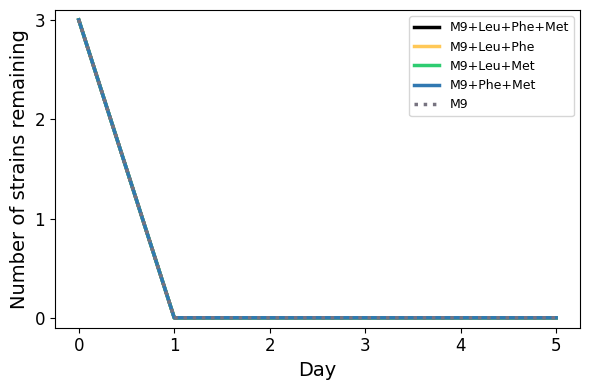

In [89]:


def plot_strain_richness_overlay(
    df_loss,
    max_day=5,
    label_color_map=None
):
    """
    Plot number of strains remaining vs time for all environments (overlay).
    """

    if label_color_map is None:
        label_color_map = {}

    days = np.arange(0, max_day + 1)

    plt.figure(figsize=(6,4))

    for _, r in df_loss.iterrows():
        label = r["label"]

        y = [r[f"n_remaining_day{d}"] for d in days]

        color = label_color_map.get(label.replace(" ", ""), None)

        linestyle = ":" if label.strip() == "M9" else "-"

        plt.plot(
            days,
            y,
            label=label,
            linewidth=2.5,
            linestyle=linestyle,
            color=color
        )

    plt.xlabel("Day", fontsize=14)
    plt.ylabel("Number of strains remaining", fontsize=14)
    plt.xticks(days, fontsize=12)
    plt.yticks([0,1,2,3], fontsize=12)
    plt.ylim(-0.1, 3.1)
    plt.legend(fontsize=9, loc="upper right")
    plt.tight_layout()
    plt.show()

plot_strain_richness_overlay(
    df_loss,
    max_day=5,
    label_color_map=LABEL_COLOR_MAP
)

In [90]:


def print_constant_richness_outcomes(df_loss, max_day=5):
    """
    Pretty-print richness outcomes for constant environments.

    Expects df_loss from summarize_strain_loss_times(...), with columns like:
      - label
      - loss_day_leuB, loss_day_pheA, loss_day_metA
      - first_strain_loss_day
      - n_remaining_day0 ... n_remaining_day{max_day}
    """

    strain_names = []
    for c in df_loss.columns:
        if c.startswith("loss_day_"):
            strain_names.append(c.replace("loss_day_", ""))

    print("\n=== Constant environments: richness outcome summary ===")

    for _, r in df_loss.iterrows():
        label = r["label"]

        first_loss = r.get("first_strain_loss_day", np.nan)
        final_richness = r.get(f"n_remaining_day{max_day}", np.nan)

        lost_by_day5 = []
        loss_detail = []

        for s in strain_names:
            loss_day = r.get(f"loss_day_{s}", np.nan)
            if pd.notna(loss_day) and loss_day <= max_day:
                lost_by_day5.append(s)
                loss_detail.append(f"{s} (day {int(loss_day)})")

        if pd.isna(first_loss):
            first_loss_txt = f"none within {max_day} days"
        else:
            first_loss_txt = f"day {int(first_loss)}"

        if len(lost_by_day5) == 0:
            lost_txt = "none"
            detail_txt = "none"
        else:
            lost_txt = ", ".join(lost_by_day5)
            detail_txt = "; ".join(loss_detail)

        print(
            f"- {label}: "
            f"first strain loss = {first_loss_txt} | "
            f"final richness (day {max_day}) = {int(final_richness)} | "
            f"lost by day {max_day}: {lost_txt} | "
            f"loss times: {detail_txt}"
        )

print_constant_richness_outcomes(df_loss, max_day=5)


=== Constant environments: richness outcome summary ===
- M9+Leu+Phe+Met: first strain loss = day 1 | final richness (day 5) = 0 | lost by day 5: leuB, pheA, metA | loss times: leuB (day 1); pheA (day 2); metA (day 1)
- M9+Leu+Phe: first strain loss = day 1 | final richness (day 5) = 0 | lost by day 5: leuB, pheA, metA | loss times: leuB (day 1); pheA (day 1); metA (day 1)
- M9+Leu+Met: first strain loss = day 1 | final richness (day 5) = 0 | lost by day 5: leuB, pheA, metA | loss times: leuB (day 1); pheA (day 2); metA (day 1)
- M9+Phe+Met: first strain loss = day 1 | final richness (day 5) = 0 | lost by day 5: leuB, pheA, metA | loss times: leuB (day 4); pheA (day 4); metA (day 1)
- M9: first strain loss = day 1 | final richness (day 5) = 0 | lost by day 5: leuB, pheA, metA | loss times: leuB (day 1); pheA (day 1); metA (day 1)


In [91]:
def get_label(traj, ruta_mapping):
    return ruta_mapping.get(traj, traj)

def _mean_od_by_day(lineage_df, max_day=5):
    """Return (days, mean_OD) with days as np.array([1..max_day]).
       Missing days are kept as NaN; caller decides how to handle."""
    g = (lineage_df.groupby("prefix_day")["OD"]
                    .mean(numeric_only=True)
                    .reindex(range(1, max_day+1)))
    days = g.index.values.astype(float)
    od = g.values.astype(float)
    return days, od

def _auc_on_days(days, od):
    """Trapezoid AUC on provided (days, od) with NaNs removed pairwise."""
    m = ~np.isnan(days) & ~np.isnan(od)
    d = days[m]; y = od[m]
    if len(d) < 2:
        return np.nan
    return float(np.trapezoid(y, d))

def _final_at_day(max_day, days, od):
    """Return OD at day=max_day (NaN if not present)."""
    hits = np.where(days == float(max_day))[0]
    if len(hits) == 0:
        return np.nan
    return float(od[hits[0]])


In [92]:

def summarize_constant_vs_baseline(lineage_frames, baseline="EEEEE", max_day=5, verbose=True):
    """
    Summarize constant environments using OD metrics,
    and compare each constant condition to a chosen baseline.

    Parameters
    ----------
    baseline : str
        Trajectory used as reference (e.g. "EEEEE" for M9).
    """

    # index by traj
    by_traj = {
        m["traj"].iloc[0]: m
        for m in lineage_frames
        if m is not None and not m.empty and "traj" in m.columns and "OD" in m.columns
    }

    if baseline not in by_traj:
        raise ValueError(f"Baseline '{baseline}' trajectory not found in lineage_frames.")

    # baseline metrics
    dA, oA = _mean_od_by_day(by_traj[baseline], max_day=max_day)
    auc_A = _auc_on_days(dA, oA)
    fin_A_raw = _final_at_day(max_day, dA, oA)
    fin_A_cmp = 0.0 if np.isnan(fin_A_raw) else float(fin_A_raw)

    rows = []

    for traj in CONSTANT_PATHS:
        if traj == baseline:
            continue

        if traj not in by_traj:
            rows.append({
                "traj": traj,
                "auc_od": np.nan,
                "final_od_raw": np.nan,
                "final_od_cmp": 0.0,
                "extinct_by_day5": True,
                "delta_auc_vs_baseline": np.nan,
                "delta_final_vs_baseline": 0.0 - fin_A_cmp,
                "better_auc_than_baseline": False,
                "better_final_than_baseline": False,
            })
            continue

        d, o = _mean_od_by_day(by_traj[traj], max_day=max_day)
        auc = _auc_on_days(d, o)
        fin_raw = _final_at_day(max_day, d, o)

        extinct = np.isnan(fin_raw)
        fin_cmp = 0.0 if extinct else float(fin_raw)

        rows.append({
            "traj": traj,
            "auc_od": auc,
            "final_od_raw": fin_raw,
            "final_od_cmp": fin_cmp,
            "extinct_by_day5": extinct,
            "delta_auc_vs_baseline": auc - auc_A if not (np.isnan(auc) or np.isnan(auc_A)) else np.nan,
            "delta_final_vs_baseline": fin_cmp - fin_A_cmp,
            "better_auc_than_baseline": (auc > auc_A) if not (np.isnan(auc) or np.isnan(auc_A)) else False,
            "better_final_than_baseline": (fin_cmp > fin_A_cmp),
        })

    out = pd.DataFrame(rows)

    if verbose:
        base_label = ruta_mapping.get(baseline, baseline)

        print(f"Baseline ({base_label}): AUC={auc_A:.4f}, Final(day {max_day})={fin_A_cmp:.4f}")
        print(f"\n=== Constant environments vs {base_label} ===")

        for _, r in out.iterrows():
            traj = r["traj"]
            label = ruta_mapping.get(traj, traj)

            final_txt = "extinct" if r["extinct_by_day5"] else f"{r['final_od_cmp']:.4f}"

            print(
                f"- {label}: "
                f"AUC={r['auc_od']:.4f} | Final={final_txt} | "
                f"ΔAUC={r['delta_auc_vs_baseline']:.4f} | "
                f"ΔFinal={r['delta_final_vs_baseline']:.4f} | "
                f"better AUC? {r['better_auc_than_baseline']} | "
                f"better Final? {r['better_final_than_baseline']}"
            )

    return out


baseline = "EEEEE"  # M9

const_vs_base = summarize_constant_vs_baseline(
    lineage_frames,
    baseline=baseline,
    max_day=5,
    verbose=True
)

Baseline (M9): AUC=0.5265, Final(day 5)=0.1700

=== Constant environments vs M9 ===
- M9+Leu+Phe+Met: AUC=1.2692 | Final=0.3673 | ΔAUC=0.7428 | ΔFinal=0.1973 | better AUC? True | better Final? True
- M9+Leu+Phe: AUC=0.9473 | Final=extinct | ΔAUC=0.4208 | ΔFinal=-0.1700 | better AUC? True | better Final? False
- M9+Leu+Met: AUC=0.6874 | Final=extinct | ΔAUC=0.1609 | ΔFinal=-0.1700 | better AUC? True | better Final? False
- M9+Phe+Met: AUC=1.2936 | Final=0.3808 | ΔAUC=0.7671 | ΔFinal=0.2108 | better AUC? True | better Final? True


In [93]:
def print_constant_outcomes(df_traj_cfu, df_loss, ruta_mapping):
    """
    Print biological outcomes for constant environments:
    extinction timing, final CFU, final richness, and strain-loss timing.
    """

    cfu_map = df_traj_cfu.set_index("traj")[["extinction_day", "final_total_cfu"]].to_dict("index")
    loss_map = df_loss.set_index("traj").to_dict("index")

    print("\n=== Constant environments: biological outcome summary ===")

    for traj in CONSTANT_PATHS:
        label = ruta_label(ruta_mapping, traj)

        cfu_info = cfu_map.get(traj, {})
        loss_info = loss_map.get(traj, {})

        ext_day = cfu_info.get("extinction_day", np.nan)
        final_cfu = cfu_info.get("final_total_cfu", np.nan)
        final_richness = loss_info.get("n_remaining_day5", np.nan)
        first_loss = loss_info.get("first_strain_loss_day", np.nan)

        if pd.isna(ext_day):
            ext_txt = "no extinction within 5 days"
        else:
            ext_txt = f"extinction day {int(ext_day)}"

        if pd.isna(first_loss):
            first_loss_txt = "none within 5 days"
        else:
            first_loss_txt = f"day {int(first_loss)}"

        print(
            f"- {label}: "
            f"first strain loss = {first_loss_txt}, "
            f"final richness = {int(final_richness) if pd.notna(final_richness) else 'NA'}, "
            f"{ext_txt}, "
            f"Final_CFU={final_cfu:.3e}"
        )

print_constant_outcomes(df_traj, df_loss, ruta_mapping)


=== Constant environments: biological outcome summary ===
- M9+Leu+Phe+Met: first strain loss = day 1, final richness = 0, extinction day 1, Final_CFU=0.000e+00
- M9+Leu+Phe: first strain loss = day 1, final richness = 0, extinction day 1, Final_CFU=0.000e+00
- M9+Leu+Met: first strain loss = day 1, final richness = 0, extinction day 1, Final_CFU=0.000e+00
- M9+Phe+Met: first strain loss = day 1, final richness = 0, extinction day 1, Final_CFU=0.000e+00
- M9: first strain loss = day 1, final richness = 0, extinction day 1, Final_CFU=0.000e+00


In [94]:
def compare_to_baseline(lineage_frames, ruta_mapping, baseline="EEEEE", max_day=5, verbose=True):
    """
    Compare non-constant trajectories to a chosen baseline trajectory.

    Parameters
    ----------
    lineage_frames : list of DataFrames
        Must contain 'traj', 'prefix_day', and 'OD'.
    ruta_mapping : dict
        Maps trajectory codes (e.g. 'EEEEE') to human-readable labels.
    baseline : str
        Trajectory used as the reference condition.
    max_day : int
        Final day for comparison.
    verbose : bool
        Whether to print a summary.

    Returns
    -------
    DataFrame with AUC/final OD comparisons vs the chosen baseline.
    """

    # index by traj
    by_traj = {
        m["traj"].iloc[0]: m
        for m in lineage_frames
        if m is not None and not m.empty and "traj" in m.columns and "OD" in m.columns
    }

    # baseline
    if baseline not in by_traj:
        raise ValueError(f"Baseline '{baseline}' trajectory not found in lineage_frames.")

    dA, oA = _mean_od_by_day(by_traj[baseline], max_day=max_day)
    auc_A = _auc_on_days(dA, oA)
    fin_A = _final_at_day(max_day, dA, oA)

    rows = []
    for traj, m in by_traj.items():
        if not isinstance(traj, str):
            continue

        if traj == baseline:
            continue  # skip baseline itself

        # non-constant only
        if traj in CONSTANT_PATHS:
            continue

        d, o = _mean_od_by_day(m, max_day=max_day)
        auc = _auc_on_days(d, o)
        fin = _final_at_day(max_day, d, o)

        # require a real day-5 value for comparison
        if np.isnan(fin):
            continue

        rows.append({
            "traj": traj,
            "label": ruta_mapping.get(traj, traj),
            "auc_od": auc,
            "final_od": fin,
            "better_auc_than_baseline": (auc > auc_A) if not np.isnan(auc_A) else np.nan,
            "better_final_than_baseline": (fin > fin_A) if not np.isnan(fin_A) else np.nan,
        })

    out = pd.DataFrame(rows)

    if out.empty:
        if verbose:
            print("No non-constant 5-day trajectories with valid day-5 OD were found.")
        return out

    # counts
    n_better_auc = int(out["better_auc_than_baseline"].fillna(False).sum())
    n_better_final = int(out["better_final_than_baseline"].fillna(False).sum())

    if verbose:
        base_label = ruta_mapping.get(baseline, baseline)
        print(f"Reference ({base_label}): AUC={auc_A:.4f}, Final(day {max_day})={fin_A:.4f}")
        print(f"Non-constant 5-day paths beating {base_label} by AUC:   {n_better_auc} / {len(out)}")
        print(f"Non-constant 5-day paths beating {base_label} by Final: {n_better_final} / {len(out)}")

    # add rank columns for convenience
    out = (
        out.assign(
            rank_auc=out["auc_od"].rank(ascending=False, method="min"),
            rank_final=out["final_od"].rank(ascending=False, method="min"),
        )
        .sort_values(
            ["better_auc_than_baseline", "better_final_than_baseline", "auc_od", "final_od"],
            ascending=[False, False, False, False],
        )
        .reset_index(drop=True)
    )

    return out

baseline_all = "AAAAA"
res_vs_A = compare_to_baseline(lineage_frames, ruta_mapping=ruta_mapping, baseline=baseline_all, max_day=5, verbose=True)



Reference (M9+Leu+Phe+Met): AUC=1.2692, Final(day 5)=0.3673
Non-constant 5-day paths beating M9+Leu+Phe+Met by AUC:   18 / 41
Non-constant 5-day paths beating M9+Leu+Phe+Met by Final: 16 / 41


### Variable environments

In [95]:


# ---------------------------------------------------
# Color by last letter
# ---------------------------------------------------
LABEL_COLOR_MAP2 = {
    "A": "#000000",
    "B": "#FFC857",
    "C": "#2ECC71",
    "D": "#3178B1",
    "E": "#000000"
}

def _node_color(prefix):
    """Return color based on last letter of prefix, or black for root."""
    if prefix == "" or len(prefix) == 0:
        return "#000000"   # root
    last = prefix[-1]
    return LABEL_COLOR_MAP2.get(last, "#000000")

# ---------------------------------------------------
# Build trie
# ---------------------------------------------------
def build_trie_from_rutas(rutas):
    G = nx.DiGraph()
    G.add_node("", day=0)
    for r in rutas:
        r = str(r).strip()
        for i in range(len(r)):
            parent = r[:i]
            child  = r[:i+1]
            if parent not in G:
                G.add_node(parent, day=len(parent))
            if child not in G:
                G.add_node(child, day=len(child))
            G.add_edge(parent, child)
    return G

# ---------------------------------------------------
# Layered positions (top-down)
# ---------------------------------------------------
def hierarchical_positions(G):
    layers = {}
    for n,d in G.nodes(data=True):
        layers.setdefault(d["day"], []).append(n)

    # Stage 1: provisional x ~ lexicographic within each layer
    x = {}
    for day in sorted(layers):
        nodes = sorted(layers[day])
        for i,n in enumerate(nodes):
            x[n] = float(i)

    # Stage 2: refine parent x as mean child x
    for day in sorted(layers, reverse=True):
        for n in layers[day]:
            kids = list(G.successors(n))
            if kids:
                x[n] = float(np.mean([x[k] for k in kids]))

    # Stage 3: normalize x across all nodes
    vals = np.array(list(x.values()), dtype=float)
    spread = np.ptp(vals)  # NumPy 2.0 safe
    if spread > 0:
        vals = (vals - vals.min()) / spread
    else:
        vals = np.zeros_like(vals)

    # Assign positions: (x_normalized, -day)
    pos = {}
    for (node, val) in zip(x.keys(), vals):
        pos[node] = (float(val), -float(G.nodes[node]["day"]))

    # Ensure any unassigned nodes still exist in pos
    for n in G.nodes:
        if n not in pos:
            pos[n] = (0.0, -float(G.nodes[n]["day"]))

    return pos


# ---------------------------------------------------
# Visualize (large canvas + small nodes + color by letter)
# ---------------------------------------------------
def visualize_ruta_trie(
    rutas,
    highlight_paths=None,
    figsize=(18, 12),    # <-- Larger canvas
    node_size=200,       # <-- Smaller nodes
    edge_alpha=0.25,
    title="Ruta prefix tree"
):

    G = build_trie_from_rutas(rutas)
    pos = hierarchical_positions(G)

    plt.figure(figsize=figsize)

    # --- base edges ---
    nx.draw_networkx_edges(G, pos, alpha=edge_alpha, width=1.0, edge_color="#888888")

    # --- base nodes (small, colored by last letter) ---
    node_colors = [_node_color(n) for n in G.nodes]
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_size,
        node_color=node_colors,
        edgecolors="#333333",
        linewidths=0.5
    )

    # labels only for day>0 prefixes
    labels = {n: n for n in G.nodes if n != ""}
    labels[""] = "0"
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)

    # --- highlight paths ---
    if highlight_paths:
        palette = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"]
        for i, pseq in enumerate(highlight_paths):
            color = palette[i % len(palette)]
            edges = []
            if pseq:
                # start from root
                edges.append(("", pseq[0]))
                for j in range(len(pseq)-1):
                    edges.append((pseq[j], pseq[j+1]))

            nx.draw_networkx_edges(G, pos, edgelist=edges, width=3.0, edge_color=color)
            nx.draw_networkx_nodes(
                G, pos,
                nodelist=([""] + pseq),
                node_size=node_size * 2,
                node_color="white",
                edgecolors=color,
                linewidths=2.0
            )

    plt.title(title, fontsize=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


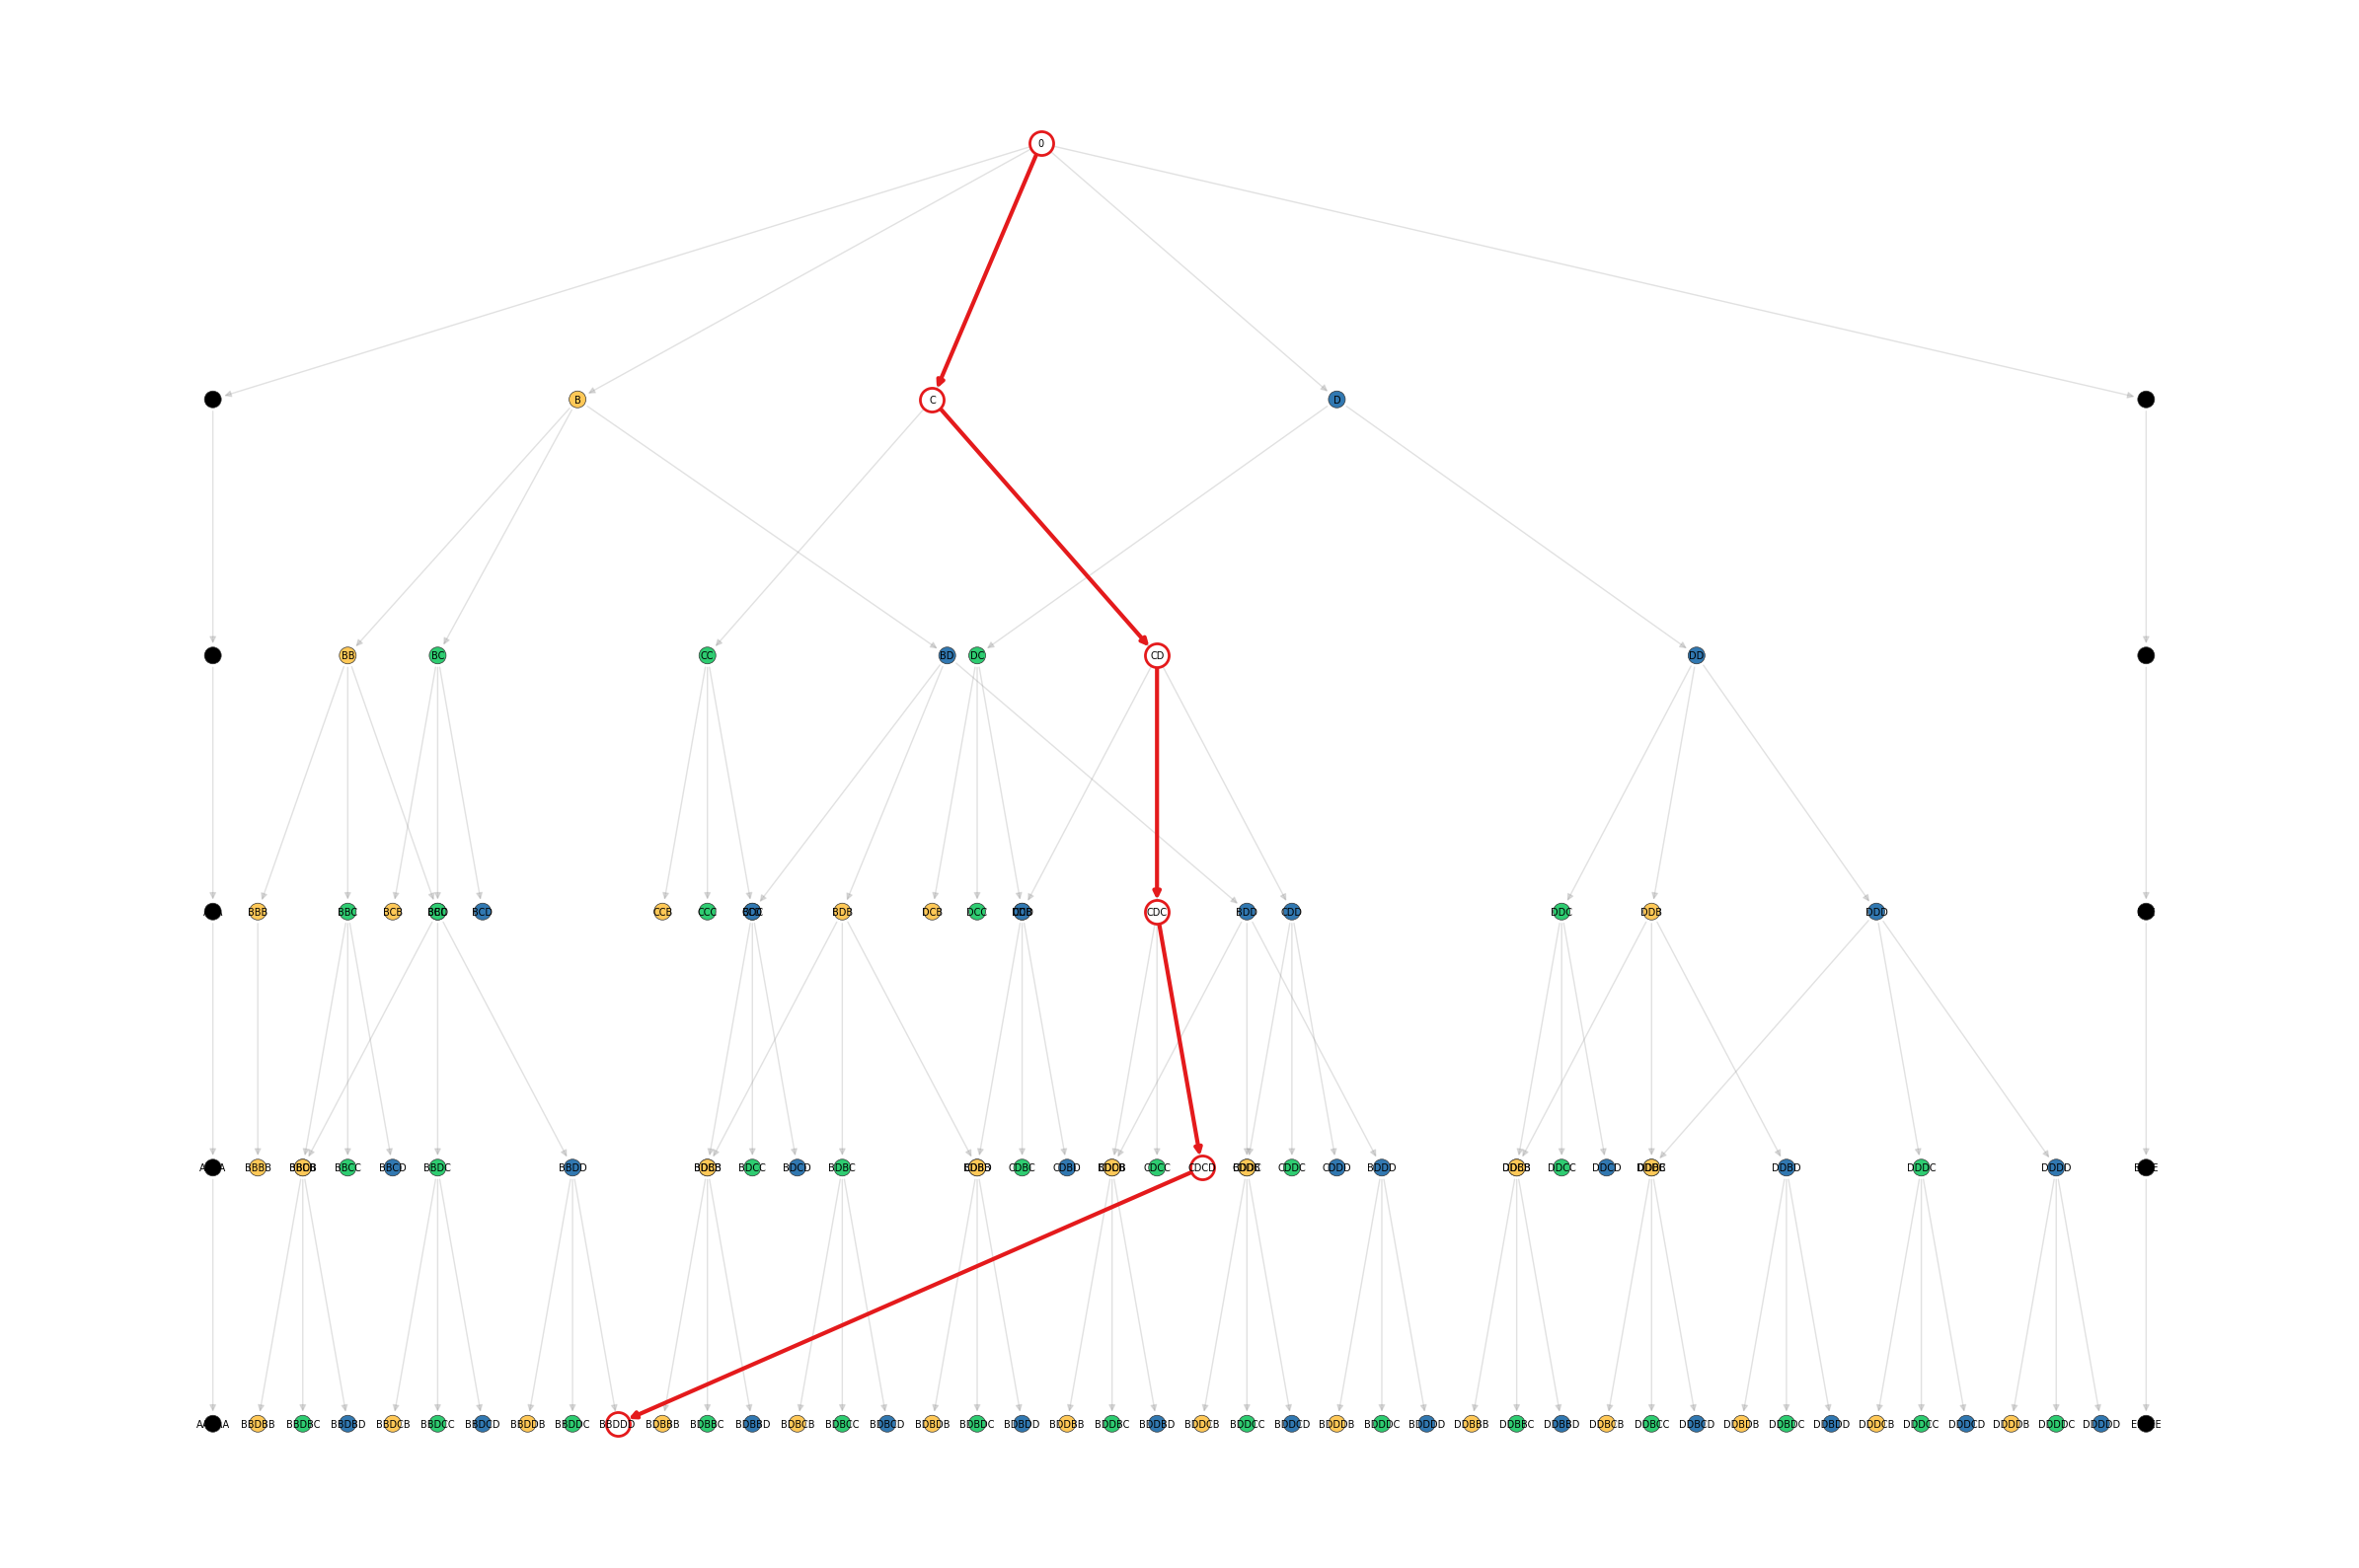

In [96]:
# All rutas from your data
rutas_all = list_all_rutas(df_od)

# Path sequences
feedback_seq = feedback_path_df["prefix"].astype(str).tolist()
optimal_seq = opt_path_df["prefix"].astype(str).tolist()

# Visualize
visualize_ruta_trie(
    rutas=rutas_all,
    highlight_paths=[feedback_seq],
    figsize=(24, 16),
    node_size=150,
    title=""
)


In [97]:
def summarize_better_than_reference(
    df,
    reference_traj,
    auc_col="diversity_auc",
    final_col="shannon_diversity",
    traj_col="traj"
):
    if df is None or df.empty:
        return {}

    if reference_traj not in set(df[traj_col]):
        raise ValueError(f"{reference_traj} not found in {traj_col}")

    ref_row = df[df[traj_col] == reference_traj].iloc[0]

    ref_auc = ref_row[auc_col]
    ref_final = ref_row[final_col]

    compare_df = df[df[traj_col] != reference_traj].copy()

    auc_better = compare_df[auc_col] > ref_auc
    final_better = compare_df[final_col] > ref_final

    n_total = len(compare_df)
    n_auc = int(auc_better.sum())
    n_final = int(final_better.sum())
    n_both = int((auc_better & final_better).sum())
    n_either = int((auc_better | final_better).sum())

    pct = lambda n: (100.0 * n / n_total) if n_total else 0.0

    print(f"Reference trajectory: {reference_traj}")
    print(f"Reference {auc_col}: {ref_auc:.4g}")
    print(f"Reference {final_col}: {ref_final:.4g}")
    print()
    print(f"Total trajectories compared: {n_total}")
    print(f"Better {auc_col}: {n_auc} ({pct(n_auc):.1f}%)")
    print(f"Better {final_col}: {n_final} ({pct(n_final):.1f}%)")
    print(f"Better on BOTH: {n_both} ({pct(n_both):.1f}%)")
    print(f"Better on EITHER: {n_either} ({pct(n_either):.1f}%)")

    return {
        "reference_traj": reference_traj,
        "ref_auc": ref_auc,
        "ref_final": ref_final,
        "n_total": n_total,
        "n_auc": n_auc,
        "n_final": n_final,
        "n_both": n_both,
        "n_either": n_either,
        "pct_auc": pct(n_auc),
        "pct_final": pct(n_final),
        "pct_both": pct(n_both),
        "pct_either": pct(n_either),
    }

In [98]:
summary = summarize_better_than_reference(
    tbl_all,
    reference_traj="AAAAA",
    auc_col="diversity_auc",
    final_col="shannon_diversity"
)

Reference trajectory: AAAAA
Reference diversity_auc: 2.835
Reference shannon_diversity: 0.1214

Total trajectories compared: 72
Better diversity_auc: 25 (34.7%)
Better shannon_diversity: 28 (38.9%)
Better on BOTH: 24 (33.3%)
Better on EITHER: 29 (40.3%)


In [99]:
summary = summarize_better_than_reference(
    tbl_all,
    reference_traj="BBDDD",
    auc_col="diversity_auc",
    final_col="shannon_diversity"
)

Reference trajectory: BBDDD
Reference diversity_auc: 2.972
Reference shannon_diversity: 0.4898

Total trajectories compared: 72
Better diversity_auc: 22 (30.6%)
Better shannon_diversity: 17 (23.6%)
Better on BOTH: 15 (20.8%)
Better on EITHER: 24 (33.3%)


In [100]:
def get_better_than_reference(
    df,
    reference_traj,
    auc_col="diversity_auc",
    final_col="shannon_diversity",
    traj_col="traj"
):
    """
    Return trajectories that outperform the reference
    in BOTH metrics.
    """

    if reference_traj not in set(df[traj_col]):
        raise ValueError(f"{reference_traj} not found")

    ref_row = df[df[traj_col] == reference_traj].iloc[0]

    ref_auc = ref_row[auc_col]
    ref_final = ref_row[final_col]

    out = df[
        (df[traj_col] != reference_traj) &
        (df[auc_col] > ref_auc) &
        (df[final_col] > ref_final)
    ].copy()

    out = out.sort_values(
        [auc_col, final_col],
        ascending=False
    )

    return out

In [101]:
better_df = get_better_than_reference(
    tbl_all,
    reference_traj="BBDDD",
    auc_col="diversity_auc",
    final_col="shannon_diversity"
)

print(better_df[[
    "traj",
    "diversity_auc",
    "shannon_diversity",
    "density_auc"
]])

     traj  diversity_auc  shannon_diversity  density_auc
0   BDBBB       4.654773           0.949986     1.472125
1   BDBBC       4.535897           0.712234     1.431500
2   BDBDB       4.427050           1.008515     1.514375
5   BDBCB       4.113138           0.762187     1.448375
6   BDBCC       4.078454           0.692820     1.457875
9   BBDBB       3.914038           1.088822     1.580875
16  BBDBC       3.715426           0.691598     1.598000
18  DDBBB       3.549527           0.952902     1.619750
10  BDDDD       3.514529           0.609598     1.459875
11  BDDDB       3.513294           0.607127     1.438687
14  DDBCB       3.446352           0.842104     1.506750
13  DDBBD       3.424618           0.703082     1.585875
12  DDBBC       3.403607           0.661061     1.535625
17  DDBCC       3.336453           0.622307     1.483250
23  BBDCB       3.006574           0.864945     1.530250


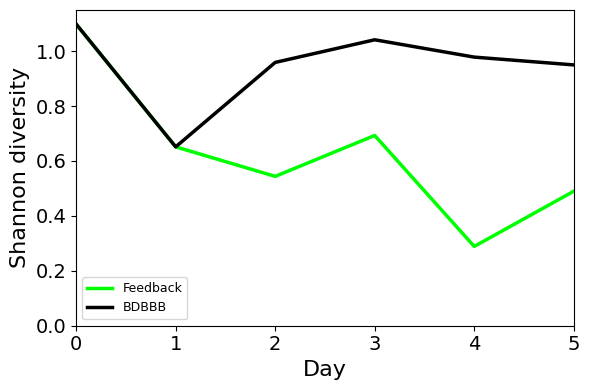

In [102]:
# Panel A: Shannon diversity vs time for all constant environments

plot_shannon_trajectories(
    merged_lineages=merged_lineages_terminal,
    highlight_rutas=['BBDDD', 'BDBBB'],
    max_day=5,
    base="e",
    show_others=False,
    label_color_map=LABEL_COLOR_MAP
)